In [1]:
# import all the necessary libraries
import os
import pysindy as ps
from pysindy.feature_library import CustomLibrary
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from custom_functions import plot_comparison, plot_pp, plot_lissajous

In [2]:
# # The van der pol oscillator system (linear coupling)
# case = 'linear'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, alpha1=1.5, alpha2=1.5,epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] +  epsilon * (x[0]-x[2]),
#            x[3],
#            lambda2 * (1-x[2]**2) * x[3] - alpha2 * x[2] + epsilon * (x[2]-x[0])]

# # The van der pol oscillator system (combination of linear and quadratic coupling)
# case = 'linear+quadratic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, linear_coeff_1=0.3, linear_coeff_2=0.3, quadratic_coeff_1=0.1, quadratic_coeff_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + linear_coeff_1 * (x[0]-x[2]) +  quadratic_coeff_1 * (x[0]-x[2])**(2),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + linear_coeff_2 * (x[2]-x[0]) + quadratic_coeff_1 * (x[2]-x[0])**(2)]



# # The van der pol oscillator system (combination of linear, quadratic and cubic coupling)
# case = 'linear+quadratic+cubic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, cubic_coefficient_1=0.1, cubic_coefficient_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + cubic_coefficient_1*(x[0]-x[2])**(3),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + cubic_coefficient_2*(x[2]-x[0])**(3)]


# # The van der pol oscillator system (exponential coupling)
# case = 'exponential'
# x0 = [1, -1, -3.5, 0.5] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.6, lambda2=1.6, omega1=1.3, omega2=1.3, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (sinusoidal coupling)
# case = 'sinusoidal'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.5, lambda2=1.5, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])]

# The van der pol oscillator system (sinusoidal+exponential coupling)
# case = 'sinusoidal+exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2])*np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])*np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (plain exponential coupling)
# case = 'plain_exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(x[2]-x[0])]


In [3]:
# # Reduced Order Model
case='ROM_model'

Cd = 1.2
CL0 = 0.5
rho0 = 1.167e-6
D = 42
U0 = 1e3
L0 = 210
lbda = 0.24
A = 12
St = 0.08
zeta = 0.2
omega1 = 18.4097
phi_expr = -0.236617

def coupled_vdp_ac(t, x, args=(Cd, CL0, rho0, D, U0, L0, lbda, A, St, zeta, omega1, phi_expr)):
    # r = x[0]
    # rdot = x[1]
    # q = x[2]
    # qdot = x[3]
    omega_s = (2 * np.pi * St * U0) / D
    alpha = (( CL0 * rho0 * D * U0 ** 2 * L0)/4) * phi_expr

    xdot = np.zeros_like(x)
    xdot[0] = x[1] 
    xdot[1] = -2 * zeta * omega1 * x[1] - (( Cd * rho0 * D * U0 * L0) / 2) * (phi_expr) ** 2 * x[1] - omega1 ** 2 * x[0] + alpha * x[2]
    xdot[2] = x[3]
    xdot[3] = (A/D) * ((phi_expr) * (xdot[1])) - lbda * omega_s * (x[2] ** 2 - 1) * x[3]- omega_s ** 2 * x[2]

    return xdot

Iteration: 0
[-0.07467963  0.21517843 -0.39715081  0.43416412]


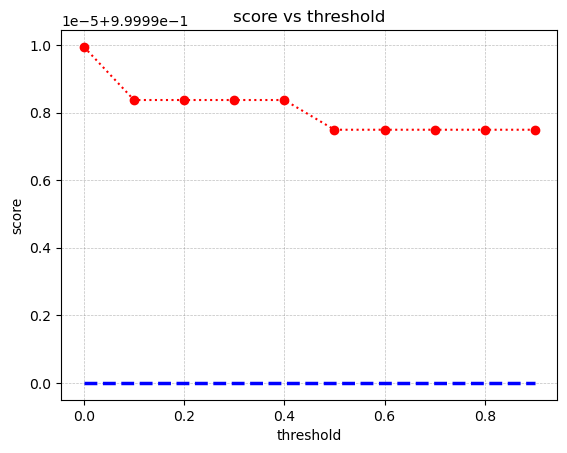

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.100 r + -7.524 r_dot + -297.109 q
(q)' = 0.997 q_dot
(q_dot)' = 7.795 r + -146.296 q + 2.863 q_dot + -2.739 q^2 q_dot
Score on training data:
0.999997491189768
Iteration: 1
[-0.4468486   0.39287655  0.00836116  0.34721351]


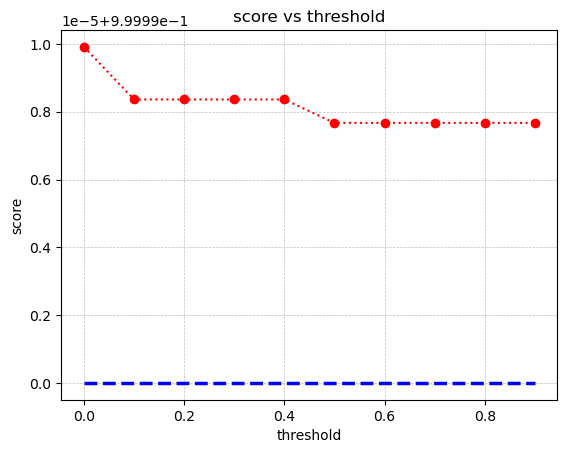

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.020 r + -7.521 r_dot + -296.976 q
(q)' = 0.997 q_dot
(q_dot)' = 7.546 r + -146.620 q + 2.876 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976713709167
Iteration: 2
[-0.28324362  0.05850563 -0.02787824 -0.04085839]


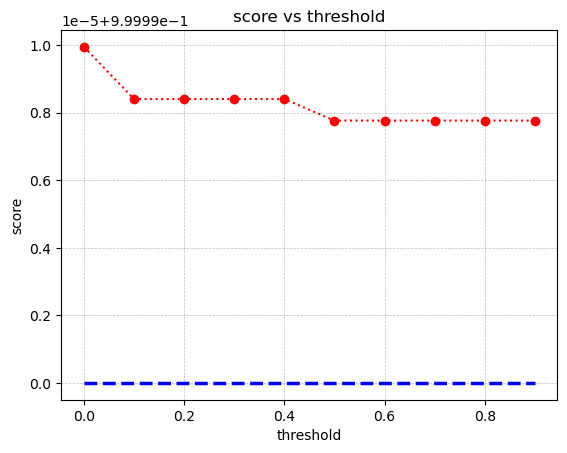

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.994 r + -7.519 r_dot + -296.933 q
(q)' = 0.997 q_dot
(q_dot)' = 7.456 r + -146.736 q + 2.880 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977689881373
Iteration: 3
[-0.07468371  0.45773058  0.01961417 -0.31748509]


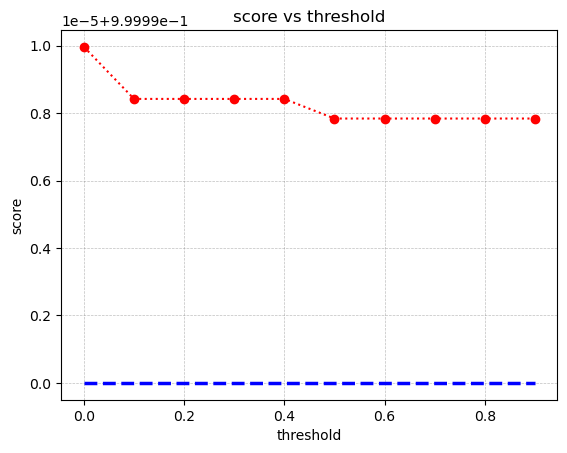

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.974 r + -7.519 r_dot + -296.899 q
(q)' = 0.997 q_dot
(q_dot)' = 7.369 r + -146.849 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978367823265
Iteration: 4
[-0.10084611  0.40658333  0.10890628 -0.02351008]


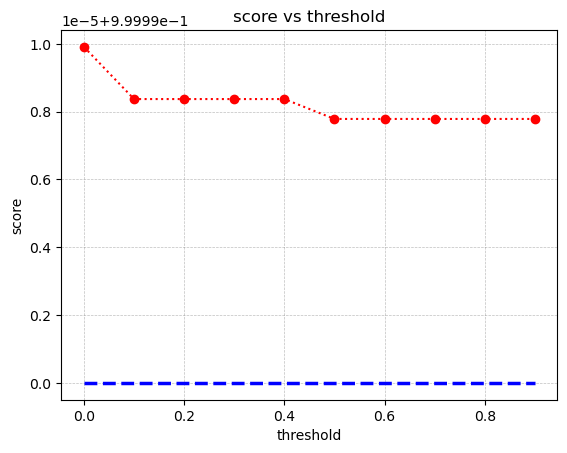

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.969 r + -7.518 r_dot + -296.890 q
(q)' = 0.997 q_dot
(q_dot)' = 7.371 r + -146.848 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977846859575
Iteration: 5
[-0.37811758 -0.42058677 -0.48625078  0.2902679 ]


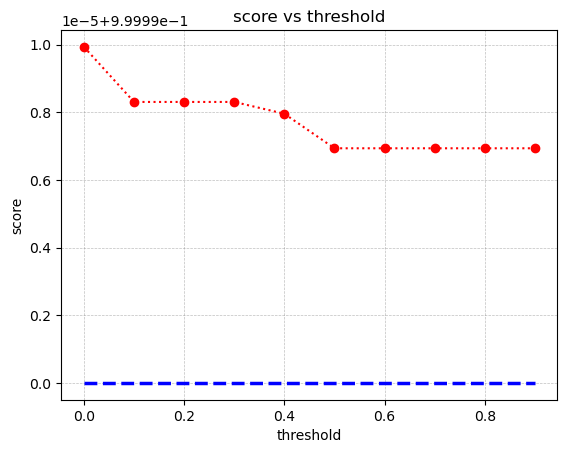

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.319 r + -7.533 r_dot + -297.471 q
(q)' = 0.997 q_dot
(q_dot)' = 8.498 r + -145.383 q + 2.828 q_dot + -2.742 q^2 q_dot
Score on training data:
0.9999969333771374
Iteration: 6
[ 0.184891    0.00318036 -0.01455427 -0.40099886]


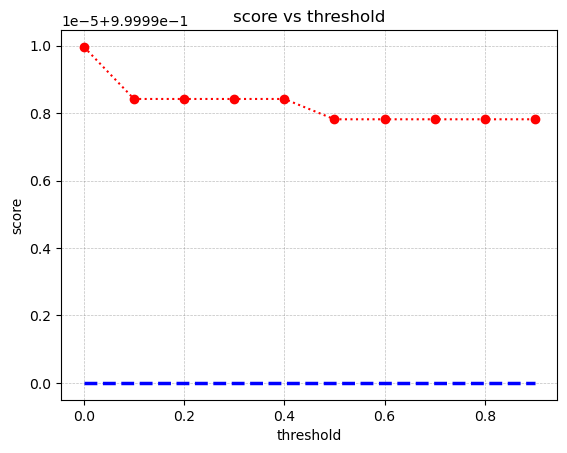

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.978 r + -7.519 r_dot + -296.906 q
(q)' = 0.997 q_dot
(q_dot)' = 7.396 r + -146.814 q + 2.883 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978174698753
Iteration: 7
[-0.20713734 -0.09912115  0.31003931 -0.45413157]


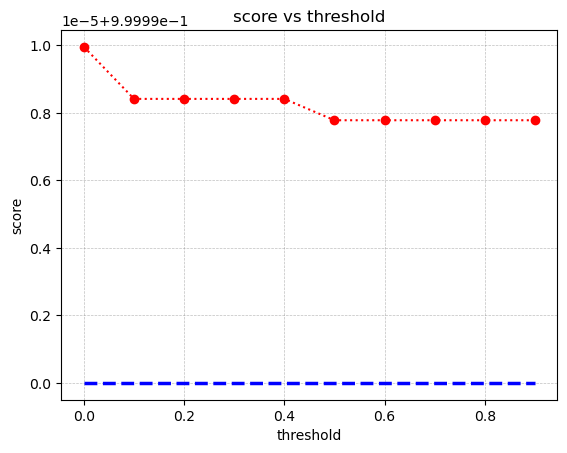

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.988 r + -7.519 r_dot + -296.922 q
(q)' = 0.997 q_dot
(q_dot)' = 7.430 r + -146.770 q + 2.881 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977796275095
Iteration: 8
[ 0.37559378 -0.39398061 -0.48828157  0.30387297]


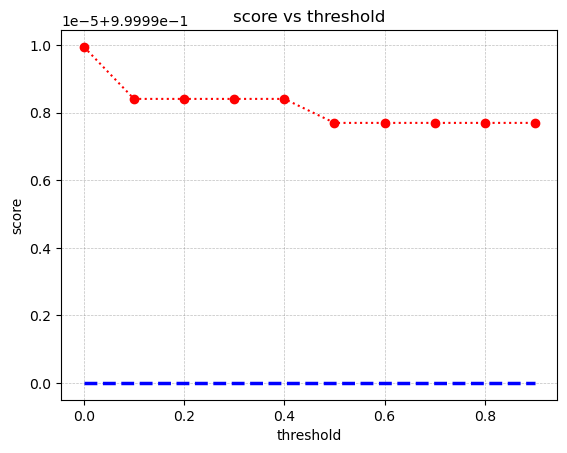

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.023 r + -7.521 r_dot + -296.981 q
(q)' = 0.997 q_dot
(q_dot)' = 7.525 r + -146.647 q + 2.877 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976985988648
Iteration: 9
[ 0.33566392 -0.45652731 -0.18873652  0.00304686]


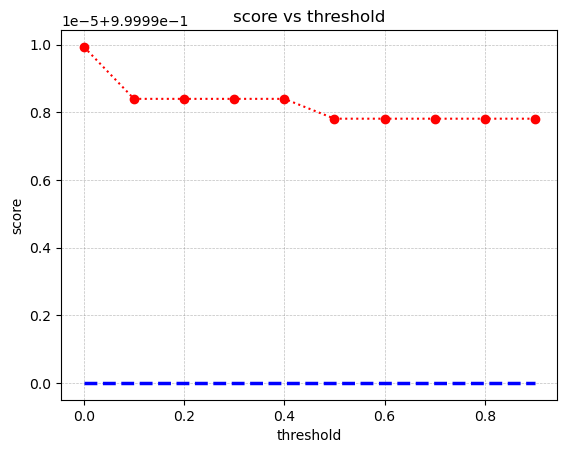

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.968 r + -7.518 r_dot + -296.888 q
(q)' = 0.997 q_dot
(q_dot)' = 7.362 r + -146.860 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978092748221
Iteration: 10
[-0.36528112  0.43030716  0.46419548 -0.00342578]


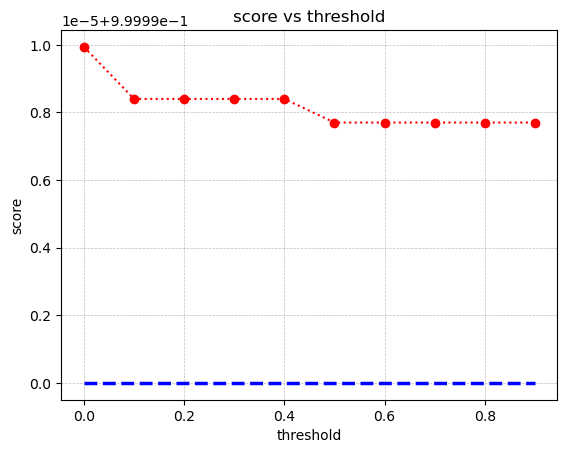

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.018 r + -7.520 r_dot + -296.972 q
(q)' = 0.997 q_dot
(q_dot)' = 7.507 r + -146.671 q + 2.877 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997701964805
Iteration: 11
[ 0.27857222  0.28534502  0.24627121 -0.46473665]


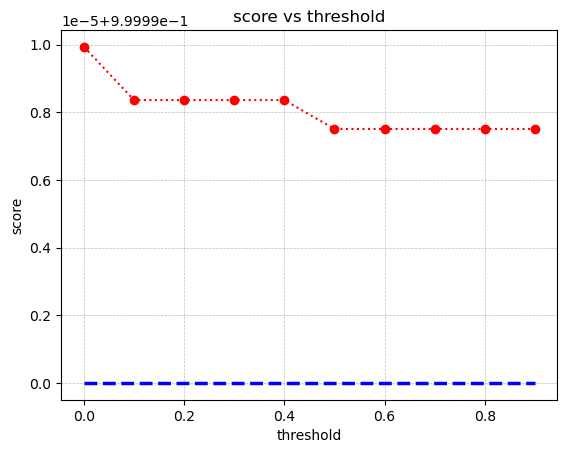

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.091 r + -7.524 r_dot + -297.093 q
(q)' = 0.997 q_dot
(q_dot)' = 7.767 r + -146.333 q + 2.865 q_dot + -2.739 q^2 q_dot
Score on training data:
0.999997505473326
Iteration: 12
[0.1982999  0.48381767 0.35739818 0.06906215]


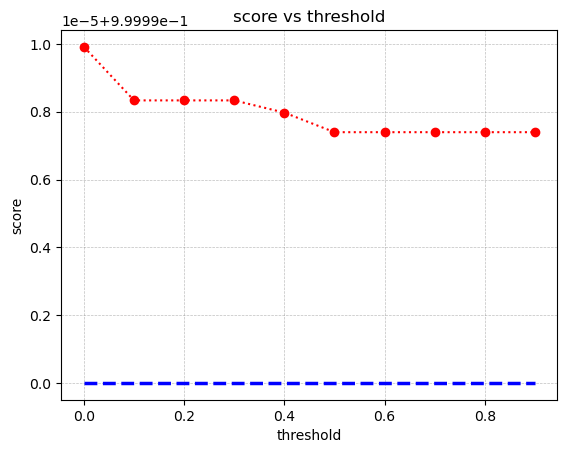

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.130 r + -7.525 r_dot + -297.157 q
(q)' = 0.997 q_dot
(q_dot)' = 7.888 r + -146.175 q + 2.859 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999973979775463
Iteration: 13
[ 0.2041136  -0.24496519  0.10903817 -0.25176301]


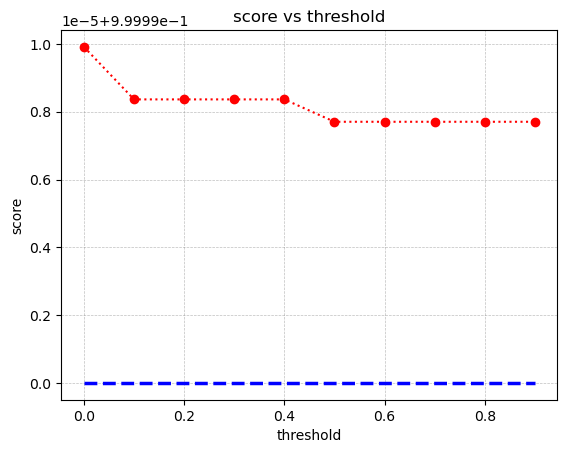

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.003 r + -7.520 r_dot + -296.947 q
(q)' = 0.997 q_dot
(q_dot)' = 7.484 r + -146.700 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977047031039
Iteration: 14
[-0.21455161 -0.10889119  0.35662025 -0.49890192]


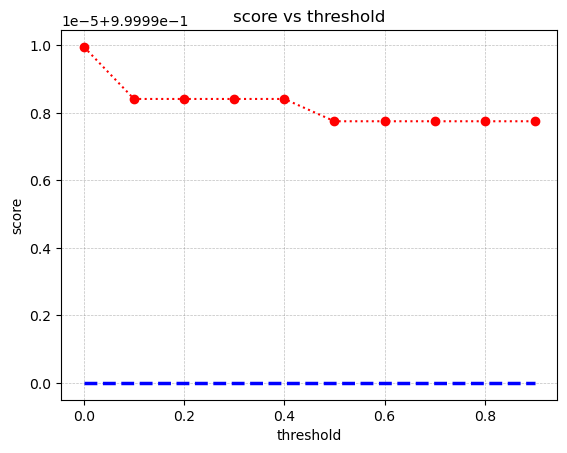

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.001 r + -7.520 r_dot + -296.944 q
(q)' = 0.997 q_dot
(q_dot)' = 7.470 r + -146.719 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977498296483
Iteration: 15
[ 0.41605165 -0.16011088 -0.10130303  0.00640764]


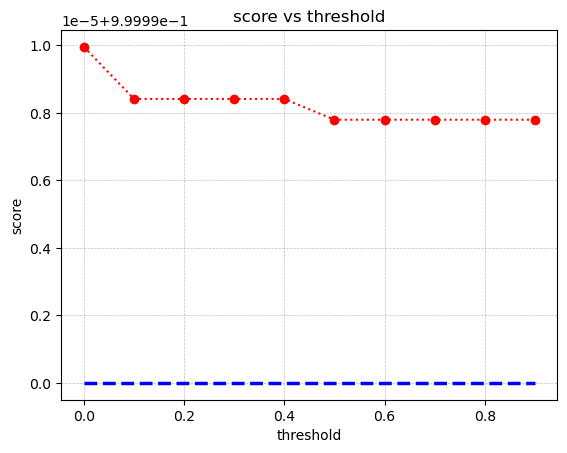

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.982 r + -7.519 r_dot + -296.913 q
(q)' = 0.997 q_dot
(q_dot)' = 7.413 r + -146.793 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977958686708
Iteration: 16
[-0.34885165  0.09682371  0.26288174 -0.18665446]


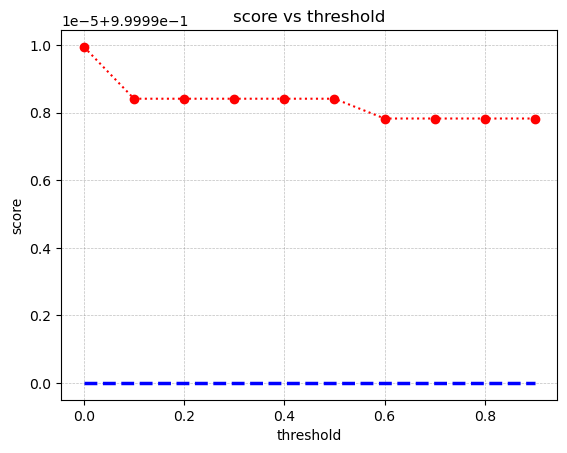

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.967 r + -7.518 r_dot + -296.888 q
(q)' = 0.997 q_dot
(q_dot)' = 7.360 r + -146.861 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978265979681
Iteration: 17
[-0.42515751 -0.20136976  0.37188144  0.44371998]


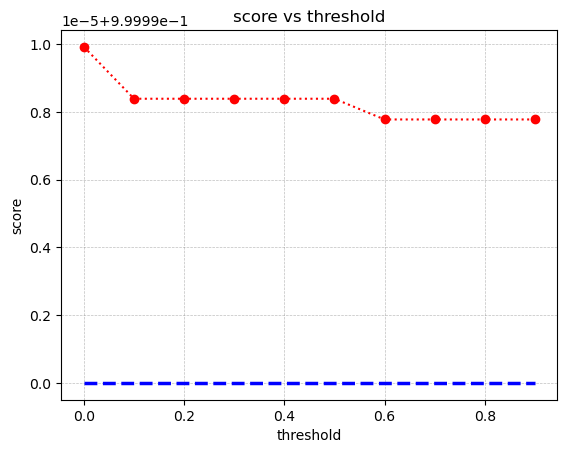

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.979 r + -7.519 r_dot + -296.908 q
(q)' = 0.997 q_dot
(q_dot)' = 7.389 r + -146.824 q + 2.883 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977799472484
Iteration: 18
[ 0.00826561  0.44830014 -0.14622924 -0.45594843]


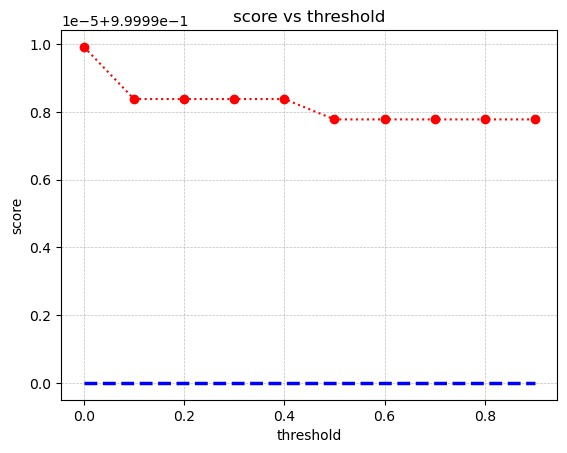

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.977 r + -7.519 r_dot + -296.904 q
(q)' = 0.997 q_dot
(q_dot)' = 7.409 r + -146.797 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977769680065
Iteration: 19
[ 0.32384887 -0.24309147 -0.43155853 -0.46198639]


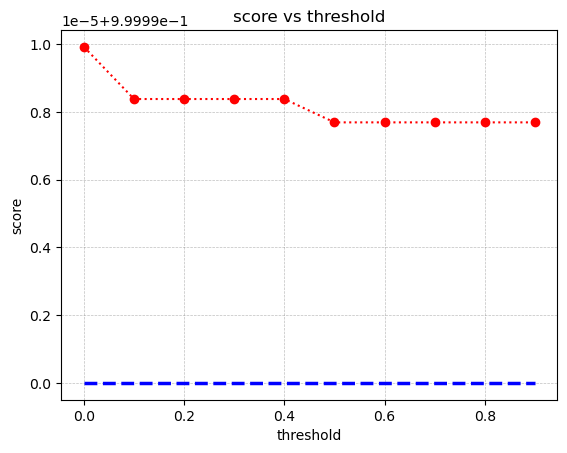

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.014 r + -7.520 r_dot + -296.965 q
(q)' = 0.997 q_dot
(q_dot)' = 7.496 r + -146.684 q + 2.878 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976928137181
Iteration: 20
[-0.27386183 -0.05600114 -0.33128583 -0.00258315]


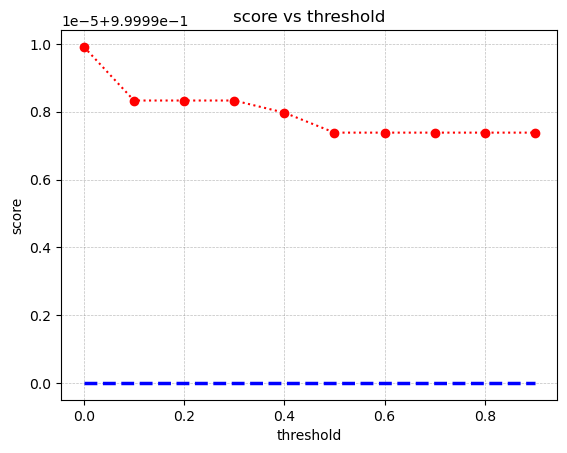

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.135 r + -7.525 r_dot + -297.165 q
(q)' = 0.997 q_dot
(q_dot)' = 7.910 r + -146.146 q + 2.857 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999973848112189
Iteration: 21
[-0.20675003  0.09873283 -0.02102641  0.00983929]


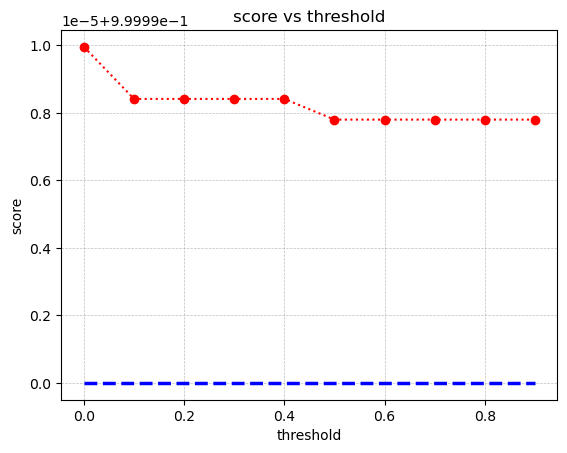

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.982 r + -7.519 r_dot + -296.912 q
(q)' = 0.997 q_dot
(q_dot)' = 7.418 r + -146.786 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978007968525
Iteration: 22
[ 0.02363994 -0.31377812 -0.43032682  0.20390809]


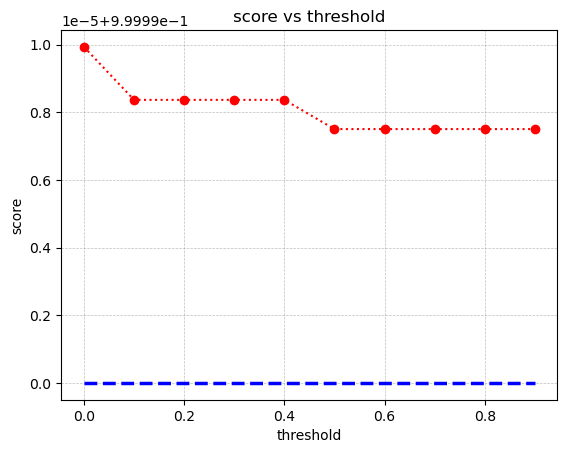

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.094 r + -7.524 r_dot + -297.097 q
(q)' = 0.997 q_dot
(q_dot)' = 7.763 r + -146.337 q + 2.865 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975059814022
Iteration: 23
[-0.25382719 -0.16353353  0.02188968  0.11958389]


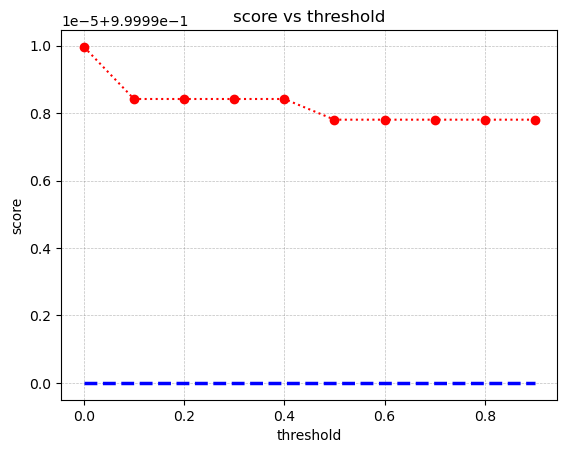

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.987 r + -7.519 r_dot + -296.920 q
(q)' = 0.997 q_dot
(q_dot)' = 7.418 r + -146.785 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978032939373
Iteration: 24
[0.19421544 0.25985705 0.28035177 0.1573097 ]


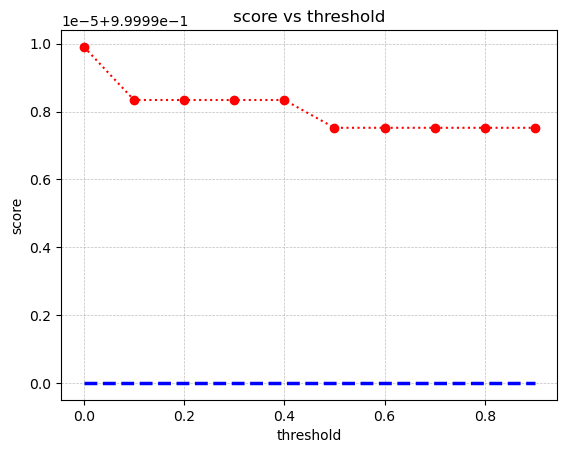

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.077 r + -7.523 r_dot + -297.070 q
(q)' = 0.997 q_dot
(q_dot)' = 7.724 r + -146.389 q + 2.867 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975208342636
Iteration: 25
[ 0.02155558 -0.02775228 -0.30409184  0.27669053]


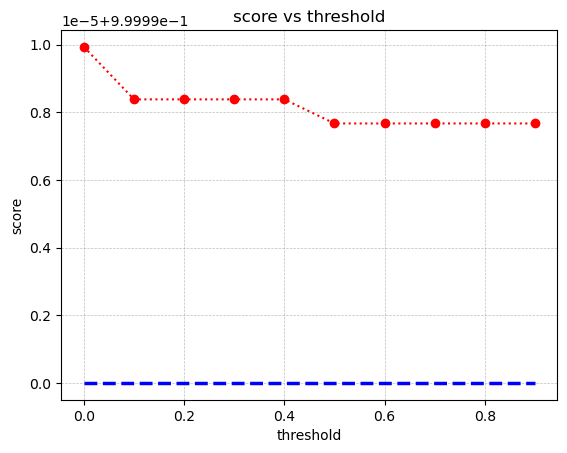

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.025 r + -7.521 r_dot + -296.984 q
(q)' = 0.997 q_dot
(q_dot)' = 7.551 r + -146.614 q + 2.875 q_dot + -2.738 q^2 q_dot
Score on training data:
0.99999767279295
Iteration: 26
[-0.1057709   0.03008819  0.33646248  0.45093826]


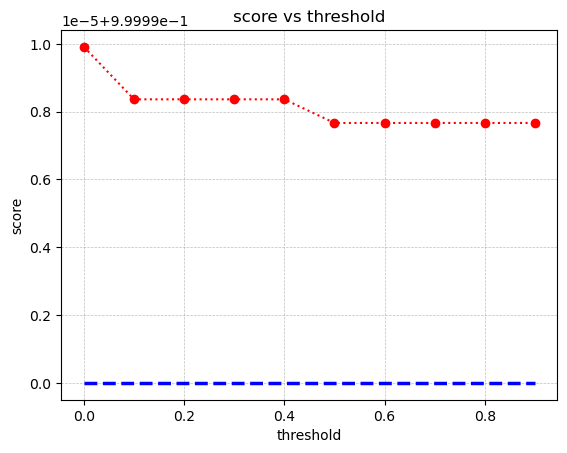

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.019 r + -7.520 r_dot + -296.973 q
(q)' = 0.997 q_dot
(q_dot)' = 7.527 r + -146.644 q + 2.877 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976662346984
Iteration: 27
[-0.45741841  0.20276571  0.28724809 -0.44807761]


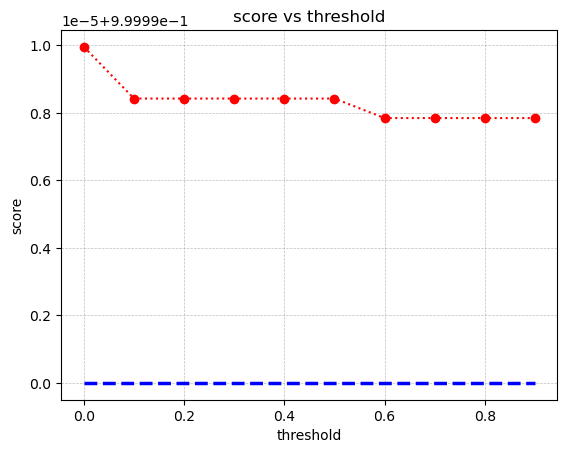

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.965 r + -7.518 r_dot + -296.885 q
(q)' = 0.997 q_dot
(q_dot)' = 7.353 r + -146.871 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978491298163
Iteration: 28
[ 0.16485162 -0.01037675  0.29466051 -0.13822973]


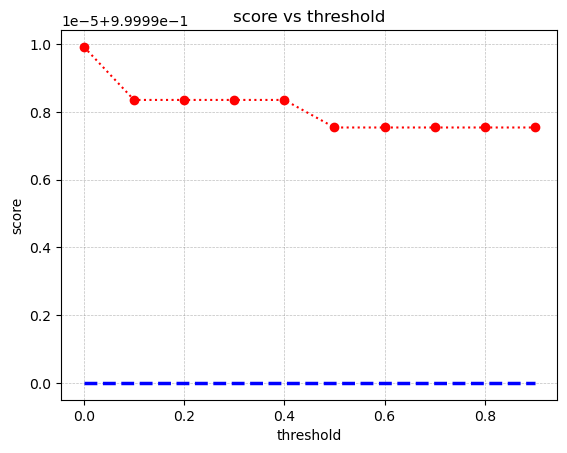

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.073 r + -7.523 r_dot + -297.063 q
(q)' = 0.997 q_dot
(q_dot)' = 7.709 r + -146.408 q + 2.867 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975421264884
Iteration: 29
[-0.26777502  0.14217718 -0.27064677  0.21085145]


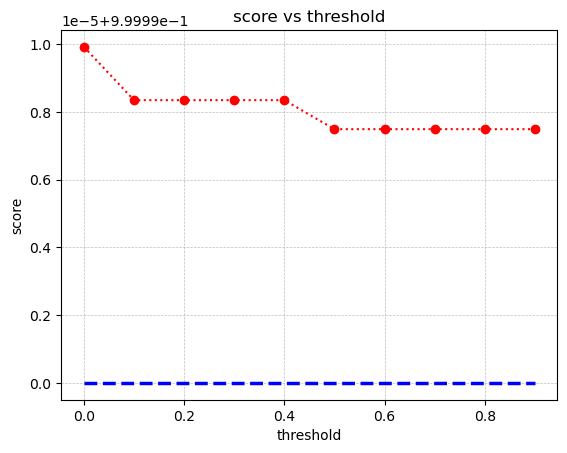

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.093 r + -7.524 r_dot + -297.096 q
(q)' = 0.997 q_dot
(q_dot)' = 7.777 r + -146.320 q + 2.864 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999974912232417
Iteration: 30
[ 0.38148103 -0.23143762 -0.27402588  0.09845658]


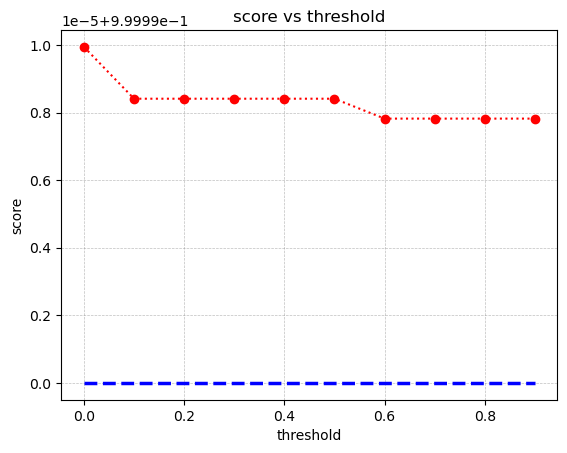

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.969 r + -7.518 r_dot + -296.890 q
(q)' = 0.997 q_dot
(q_dot)' = 7.362 r + -146.859 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978206996322
Iteration: 31
[-0.28777605 -0.13172199  0.31316392  0.08246631]


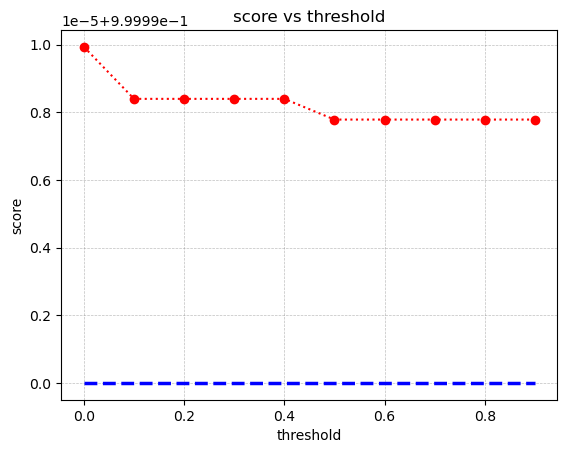

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.979 r + -7.519 r_dot + -296.907 q
(q)' = 0.997 q_dot
(q_dot)' = 7.396 r + -146.815 q + 2.883 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977835724889
Iteration: 32
[ 0.00582213 -0.39467095 -0.47322073 -0.23027957]


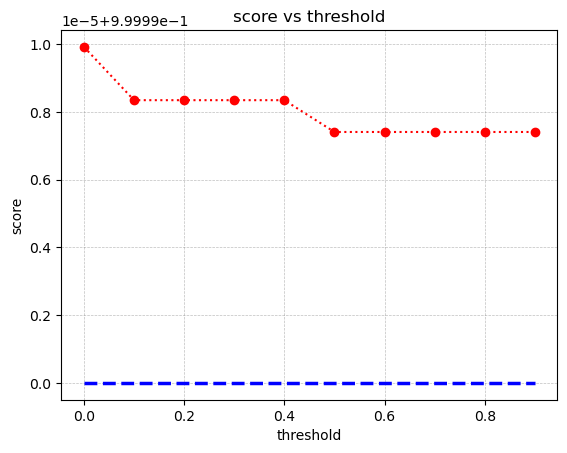

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.128 r + -7.525 r_dot + -297.154 q
(q)' = 0.997 q_dot
(q_dot)' = 7.870 r + -146.199 q + 2.859 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999974103327541
Iteration: 33
[-0.09103442  0.24801548  0.32577855  0.26381219]


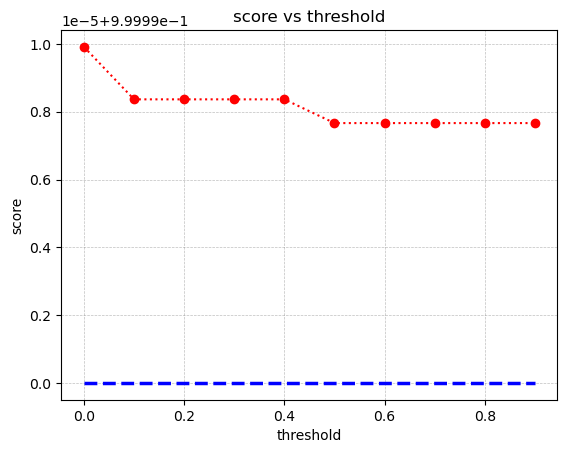

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.020 r + -7.521 r_dot + -296.976 q
(q)' = 0.997 q_dot
(q_dot)' = 7.531 r + -146.639 q + 2.876 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976660099302
Iteration: 34
[-0.33448183 -0.38402727 -0.06836114 -0.18438283]


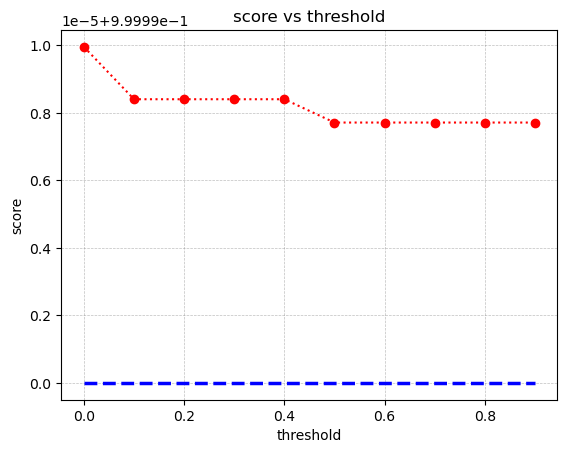

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.020 r + -7.521 r_dot + -296.975 q
(q)' = 0.997 q_dot
(q_dot)' = 7.542 r + -146.624 q + 2.876 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977134080723
Iteration: 35
[ 0.44436846 -0.39907271 -0.14341383  0.30598266]


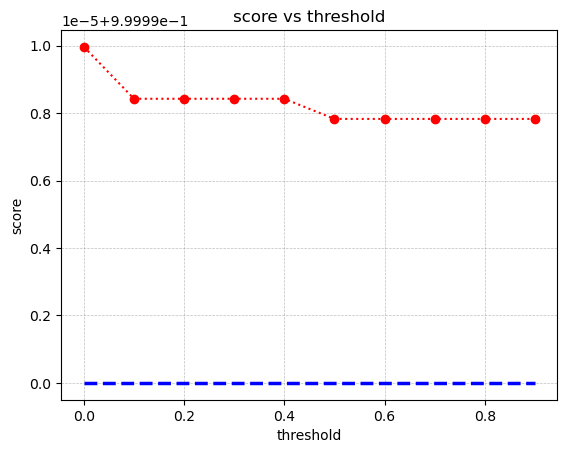

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.976 r + -7.519 r_dot + -296.902 q
(q)' = 0.997 q_dot
(q_dot)' = 7.392 r + -146.819 q + 2.883 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978264886196
Iteration: 36
[-0.12990283 -0.06709024  0.35298553 -0.26034214]


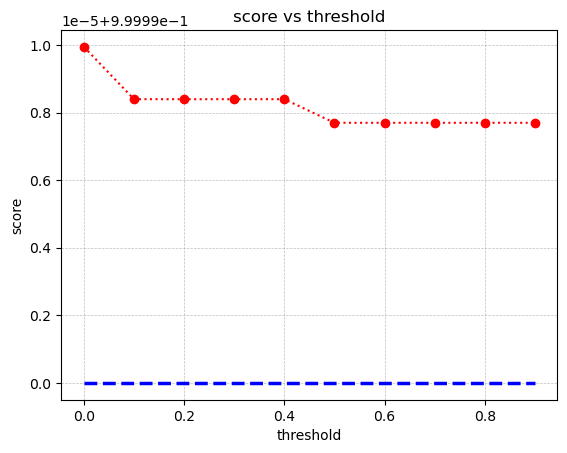

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.018 r + -7.520 r_dot + -296.972 q
(q)' = 0.997 q_dot
(q_dot)' = 7.525 r + -146.647 q + 2.877 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976961034771
Iteration: 37
[-0.28979465 -0.24773091 -0.25287661  0.4182385 ]


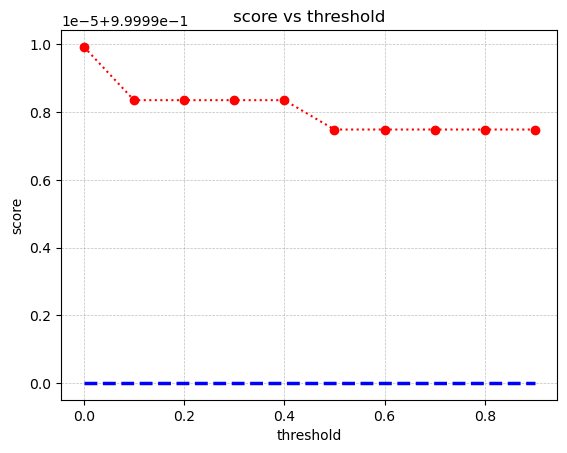

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.098 r + -7.524 r_dot + -297.105 q
(q)' = 0.997 q_dot
(q_dot)' = 7.789 r + -146.303 q + 2.863 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999974862689153
Iteration: 38
[-0.22622932 -0.36374275 -0.39718628  0.3394283 ]


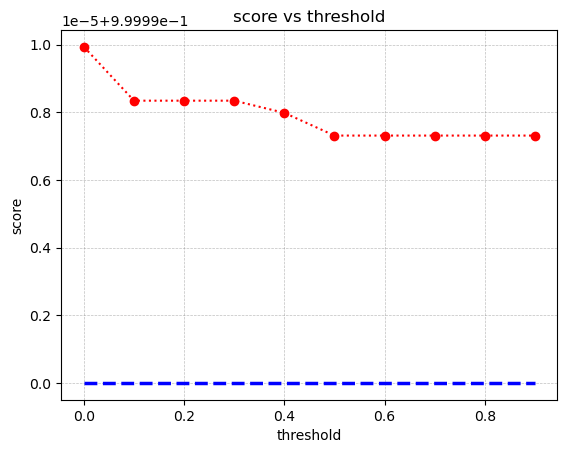

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.170 r + -7.527 r_dot + -297.224 q
(q)' = 0.997 q_dot
(q_dot)' = 8.018 r + -146.007 q + 2.852 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999973111424809
Iteration: 39
[-0.1794167   0.41182015  0.36829264  0.18436355]


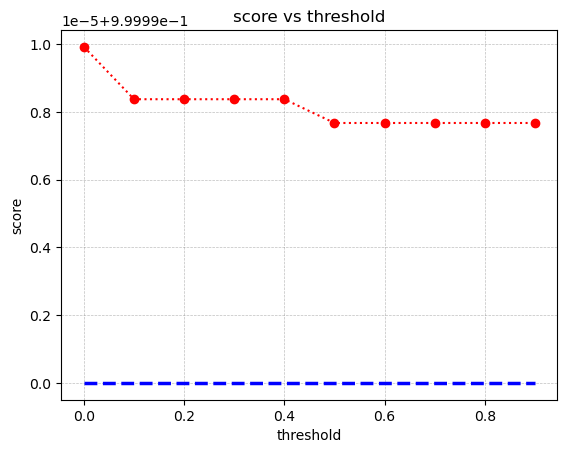

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.020 r + -7.521 r_dot + -296.975 q
(q)' = 0.997 q_dot
(q_dot)' = 7.524 r + -146.648 q + 2.877 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976759218422
Iteration: 40
[ 0.12446495 -0.10771509  0.49035984 -0.20297538]


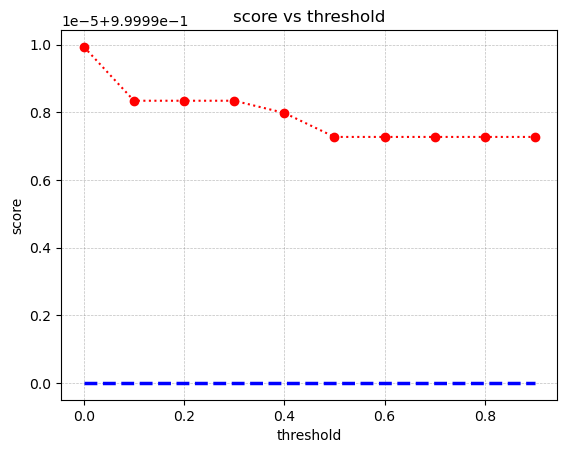

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.186 r + -7.527 r_dot + -297.250 q
(q)' = 0.997 q_dot
(q_dot)' = 8.066 r + -145.944 q + 2.850 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999972733818856
Iteration: 41
[ 0.37083778  0.00180546 -0.08995133 -0.48991303]


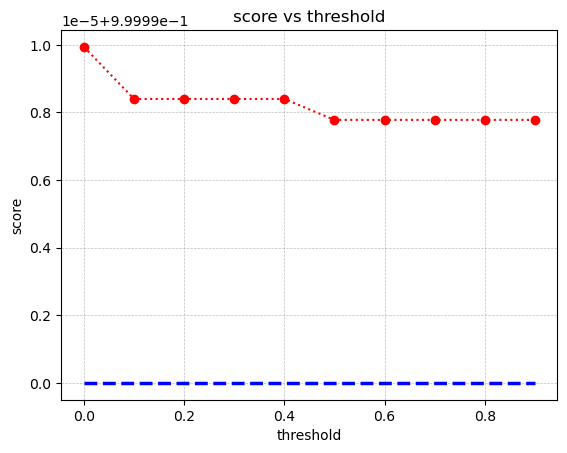

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.986 r + -7.519 r_dot + -296.919 q
(q)' = 0.997 q_dot
(q_dot)' = 7.432 r + -146.767 q + 2.881 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977794408893
Iteration: 42
[-0.18613094  0.46478506  0.3239194  -0.0049932 ]


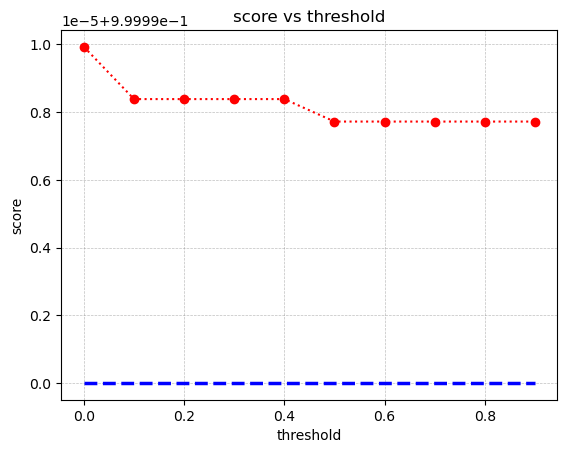

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.003 r + -7.520 r_dot + -296.947 q
(q)' = 0.997 q_dot
(q_dot)' = 7.470 r + -146.718 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977228815897
Iteration: 43
[-0.38970249 -0.38012619  0.18937412  0.11138862]


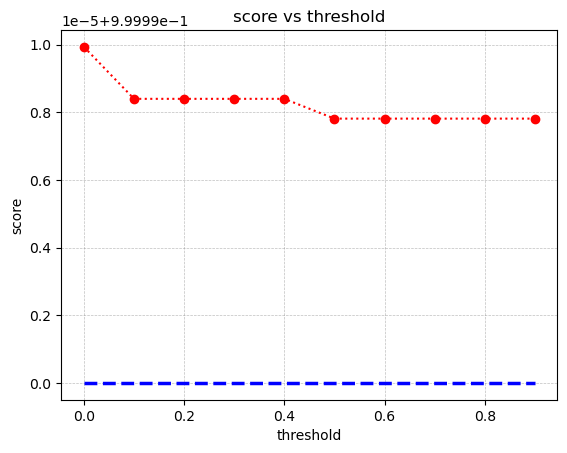

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.968 r + -7.518 r_dot + -296.888 q
(q)' = 0.997 q_dot
(q_dot)' = 7.363 r + -146.858 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978117182032
Iteration: 44
[ 0.10857051  0.48512852 -0.20153211 -0.21940193]


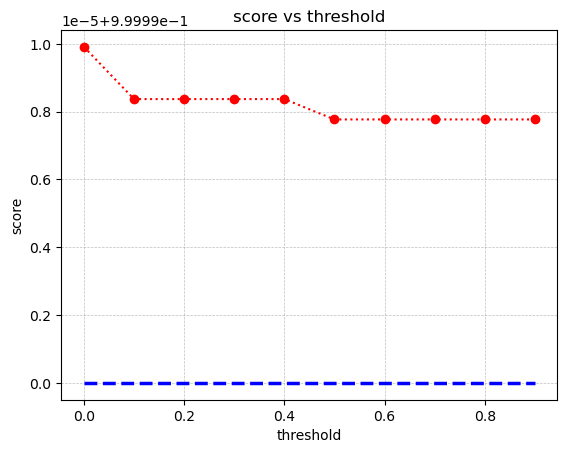

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.975 r + -7.519 r_dot + -296.901 q
(q)' = 0.997 q_dot
(q_dot)' = 7.393 r + -146.819 q + 2.883 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977695918164
Iteration: 45
[-0.37894402 -0.3810714   0.4953961  -0.20482869]


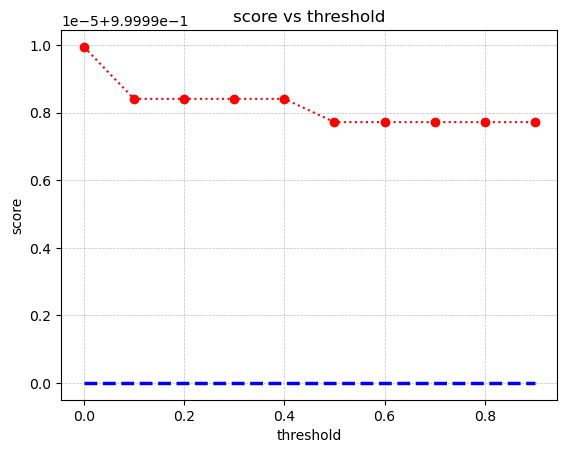

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.014 r + -7.520 r_dot + -296.965 q
(q)' = 0.997 q_dot
(q_dot)' = 7.501 r + -146.679 q + 2.878 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977205467534
Iteration: 46
[ 0.09031135 -0.39306142  0.05614936 -0.18740115]


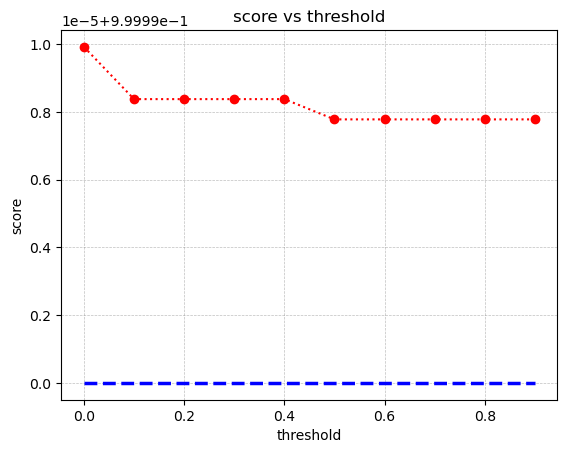

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.973 r + -7.519 r_dot + -296.898 q
(q)' = 0.997 q_dot
(q_dot)' = 7.387 r + -146.826 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977798876141
Iteration: 47
[ 0.42832228 -0.41184112  0.26077666 -0.21001944]


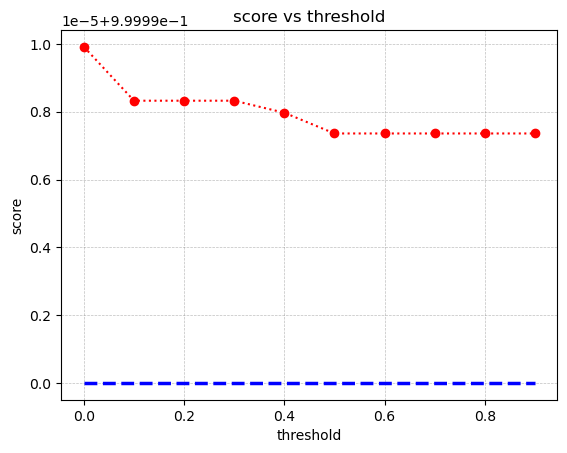

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.145 r + -7.526 r_dot + -297.182 q
(q)' = 0.997 q_dot
(q_dot)' = 7.948 r + -146.098 q + 2.856 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999973600638667
Iteration: 48
[ 0.24665073 -0.16618283 -0.42034637 -0.41992364]


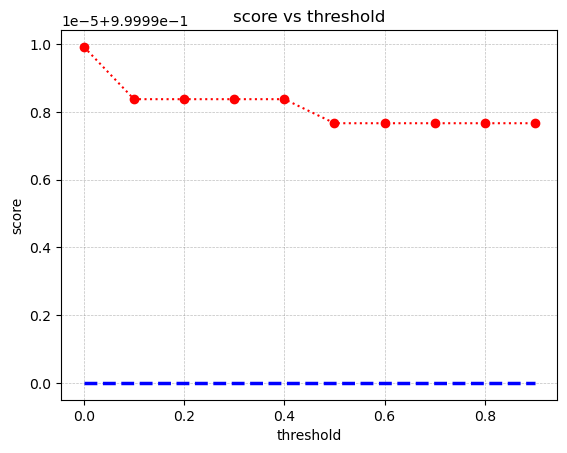

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.024 r + -7.521 r_dot + -296.981 q
(q)' = 0.997 q_dot
(q_dot)' = 7.532 r + -146.638 q + 2.876 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976664588296
Iteration: 49
[ 0.3524323   0.34376853  0.20359558 -0.03437265]


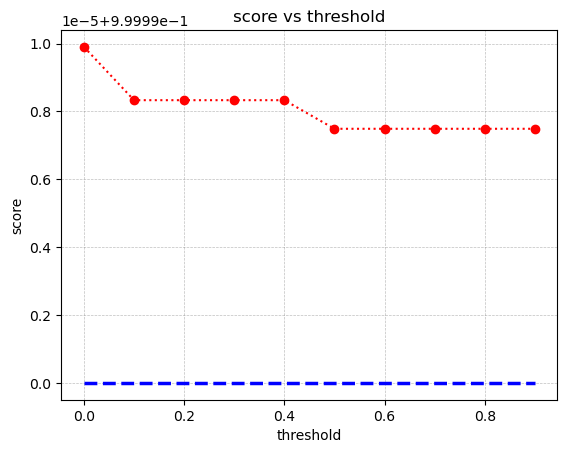

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.090 r + -7.523 r_dot + -297.091 q
(q)' = 0.997 q_dot
(q_dot)' = 7.768 r + -146.331 q + 2.865 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999974886755587
Iteration: 50
[ 0.31694325 -0.25473243  0.48442789 -0.16368126]


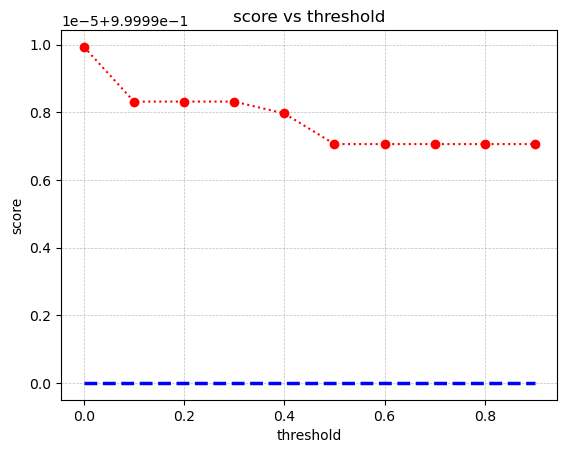

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.269 r + -7.531 r_dot + -297.389 q
(q)' = 0.997 q_dot
(q_dot)' = 8.342 r + -145.585 q + 2.836 q_dot + -2.741 q^2 q_dot
Score on training data:
0.9999970571417952
Iteration: 51
[-0.4481452   0.48076938  0.3394194   0.01889817]


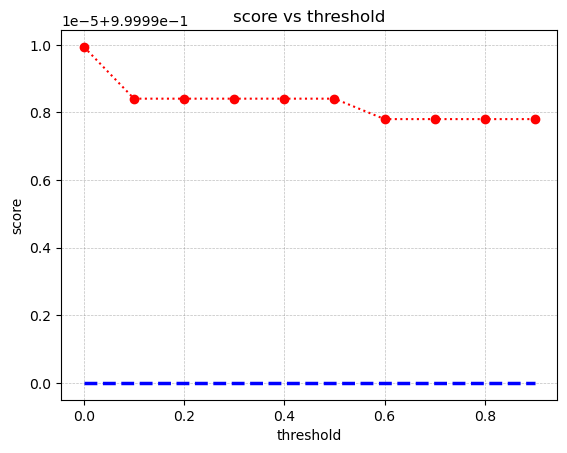

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.976 r + -7.519 r_dot + -296.902 q
(q)' = 0.997 q_dot
(q_dot)' = 7.377 r + -146.839 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978031133553
Iteration: 52
[-0.45651914 -0.17397715  0.43938825  0.3436505 ]


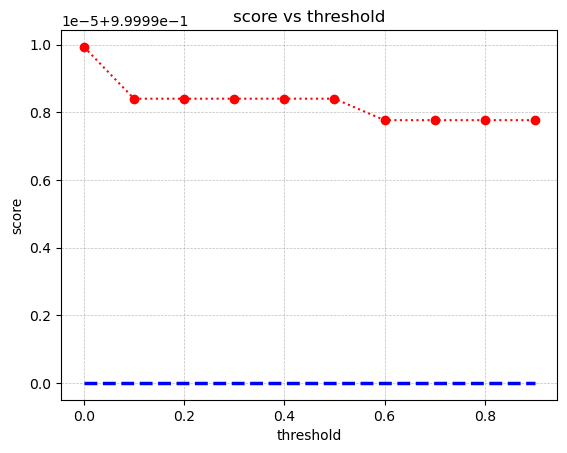

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.989 r + -7.519 r_dot + -296.924 q
(q)' = 0.997 q_dot
(q_dot)' = 7.416 r + -146.789 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977661999767
Iteration: 53
[-0.07185256 -0.19175767  0.06470749 -0.28964147]


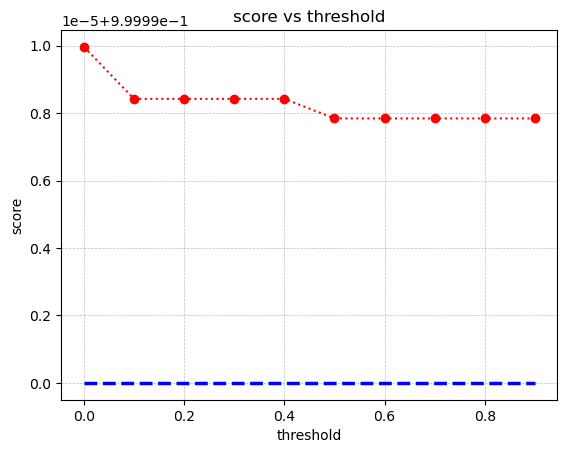

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.966 r + -7.518 r_dot + -296.885 q
(q)' = 0.997 q_dot
(q_dot)' = 7.361 r + -146.859 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978399842383
Iteration: 54
[-0.49618089  0.22578887  0.12909776 -0.13246675]


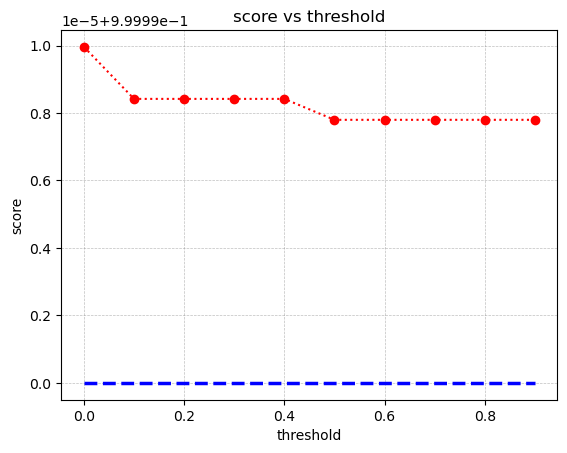

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.987 r + -7.519 r_dot + -296.920 q
(q)' = 0.997 q_dot
(q_dot)' = 7.427 r + -146.774 q + 2.881 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997798575611
Iteration: 55
[ 0.08661039 -0.4605452  -0.20378026 -0.25851589]


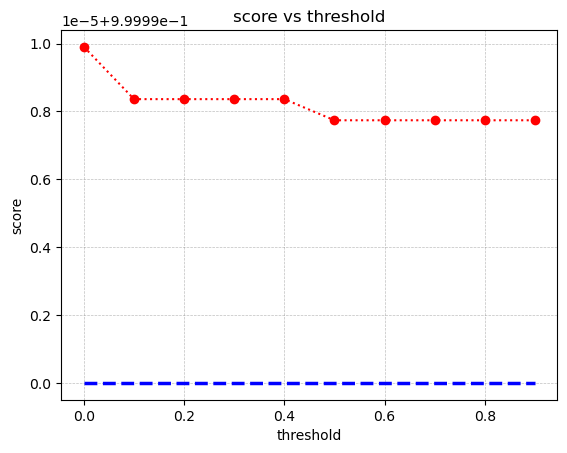

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.986 r + -7.519 r_dot + -296.919 q
(q)' = 0.997 q_dot
(q_dot)' = 7.426 r + -146.776 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977405641989
Iteration: 56
[ 0.09876044  0.21415299 -0.01291271 -0.11938104]


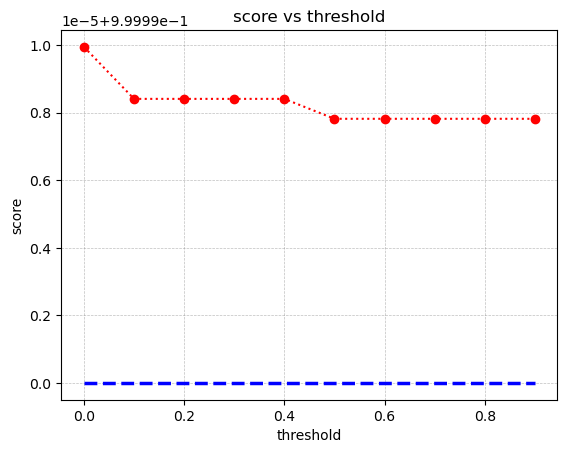

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.970 r + -7.518 r_dot + -296.893 q
(q)' = 0.997 q_dot
(q_dot)' = 7.376 r + -146.840 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978206214413
Iteration: 57
[ 0.27472316  0.02579317  0.04460343 -0.37718724]


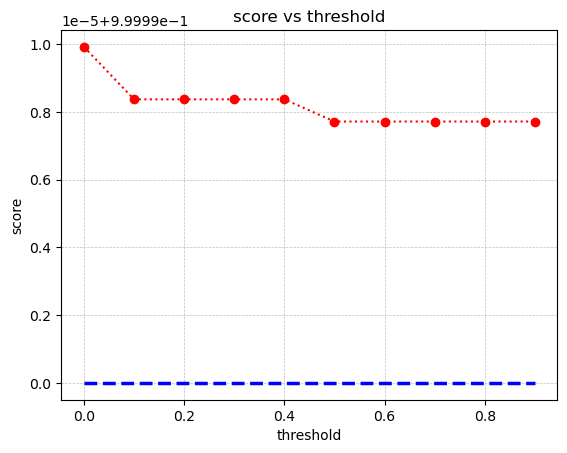

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.000 r + -7.520 r_dot + -296.943 q
(q)' = 0.997 q_dot
(q_dot)' = 7.473 r + -146.714 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997715229837
Iteration: 58
[ 0.2000224  -0.04542169 -0.19980757  0.3162334 ]


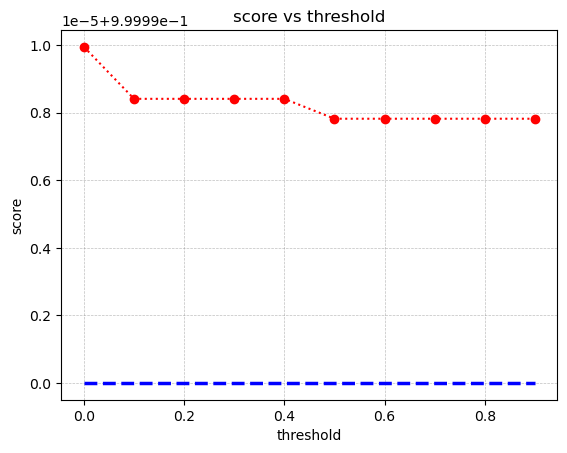

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.969 r + -7.518 r_dot + -296.890 q
(q)' = 0.997 q_dot
(q_dot)' = 7.369 r + -146.850 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978224641493
Iteration: 59
[ 0.39106533  0.09421517  0.33761066 -0.27683683]


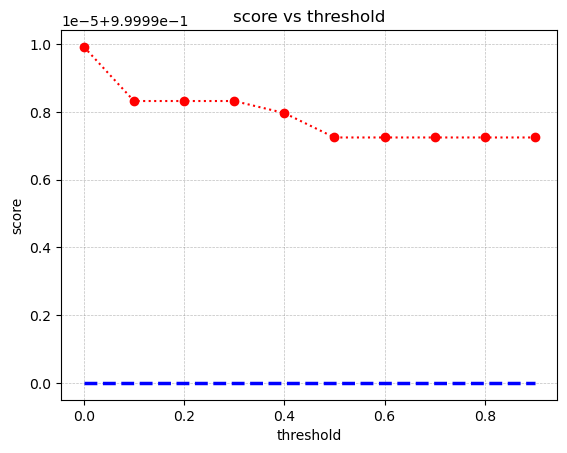

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.193 r + -7.528 r_dot + -297.261 q
(q)' = 0.997 q_dot
(q_dot)' = 8.098 r + -145.903 q + 2.848 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999972476835945
Iteration: 60
[-0.17915635 -0.04384225  0.4475451   0.03179839]


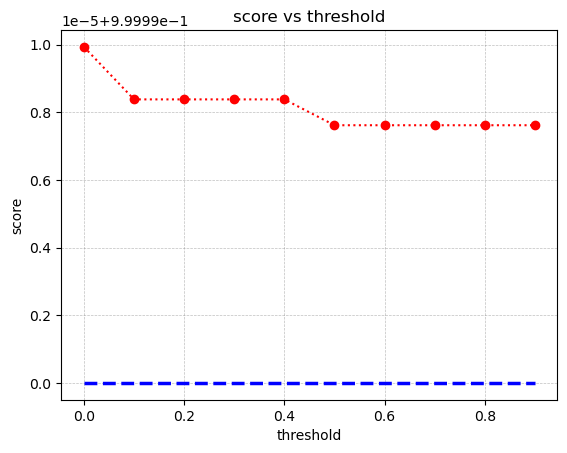

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.048 r + -7.522 r_dot + -297.022 q
(q)' = 0.997 q_dot
(q_dot)' = 7.614 r + -146.531 q + 2.872 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999976182103784
Iteration: 61
[-0.26755016  0.31266146 -0.12131102  0.08816129]


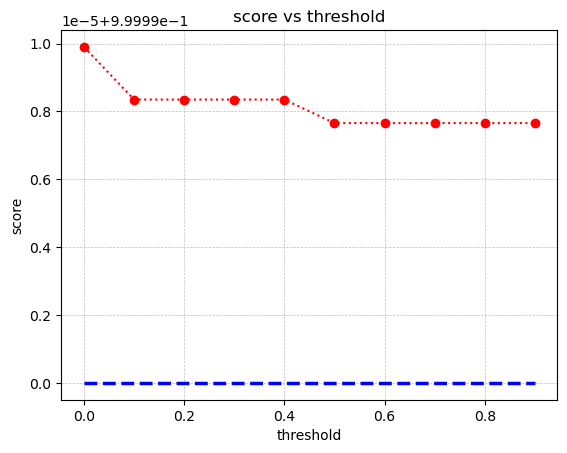

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.020 r + -7.521 r_dot + -296.975 q
(q)' = 0.997 q_dot
(q_dot)' = 7.544 r + -146.622 q + 2.876 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976562635355
Iteration: 62
[-0.35837466 -0.32197938  0.41626951 -0.0984313 ]


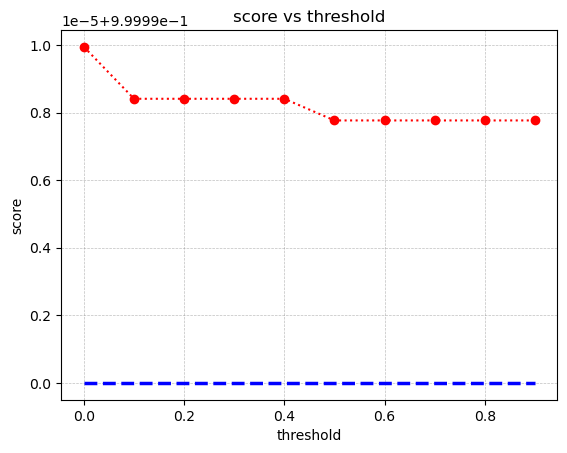

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.992 r + -7.519 r_dot + -296.929 q
(q)' = 0.997 q_dot
(q_dot)' = 7.434 r + -146.765 q + 2.881 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977679919009
Iteration: 63
[-0.16736423 -0.27360653 -0.47339262 -0.14930554]


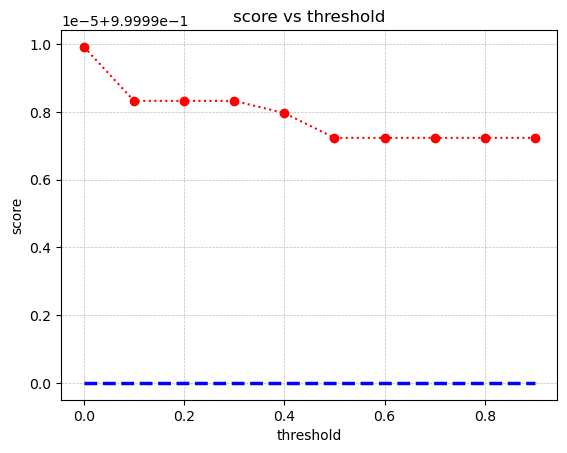

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.197 r + -7.528 r_dot + -297.269 q
(q)' = 0.997 q_dot
(q_dot)' = 8.100 r + -145.899 q + 2.848 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999972354724435
Iteration: 64
[ 0.10759476  0.47466273 -0.31569472  0.02703371]


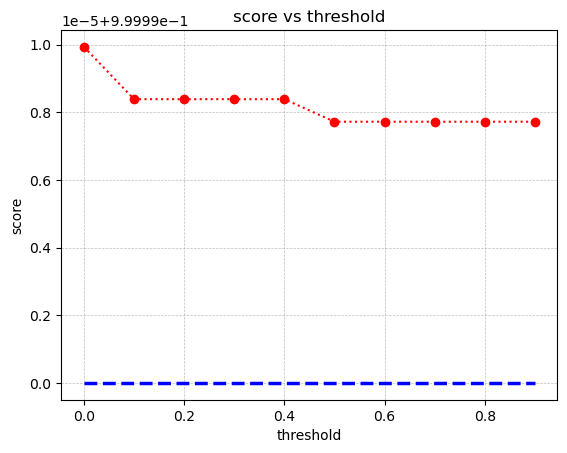

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.004 r + -7.520 r_dot + -296.948 q
(q)' = 0.997 q_dot
(q_dot)' = 7.483 r + -146.702 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977197035167
Iteration: 65
[-0.1541063  -0.02949368 -0.35338162 -0.23485328]


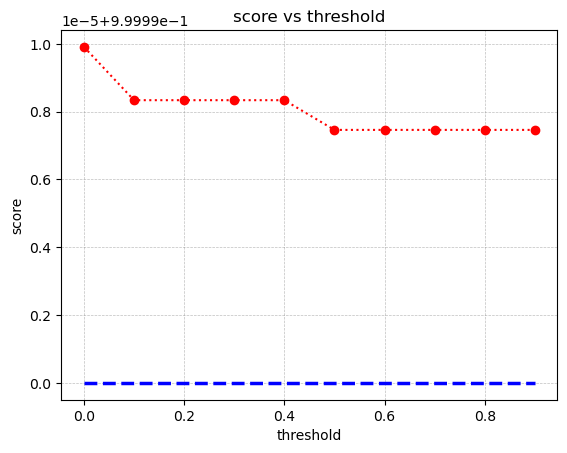

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.102 r + -7.524 r_dot + -297.111 q
(q)' = 0.997 q_dot
(q_dot)' = 7.802 r + -146.287 q + 2.863 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999974630881896
Iteration: 66
[-0.20491072  0.17431003  0.02982918  0.02814981]


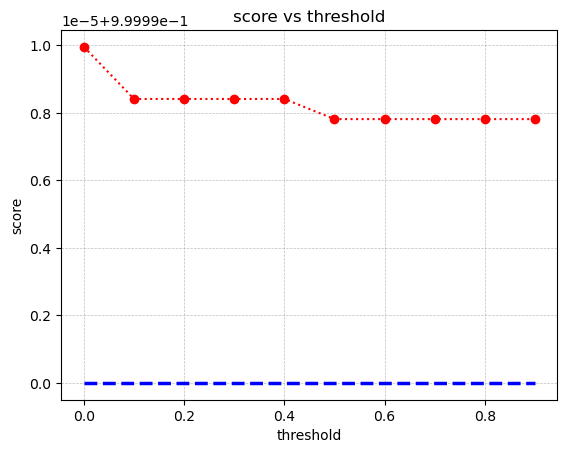

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.973 r + -7.519 r_dot + -296.897 q
(q)' = 0.997 q_dot
(q_dot)' = 7.384 r + -146.829 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997815581985
Iteration: 67
[-0.38629676 -0.07081208  0.4664099  -0.40271017]


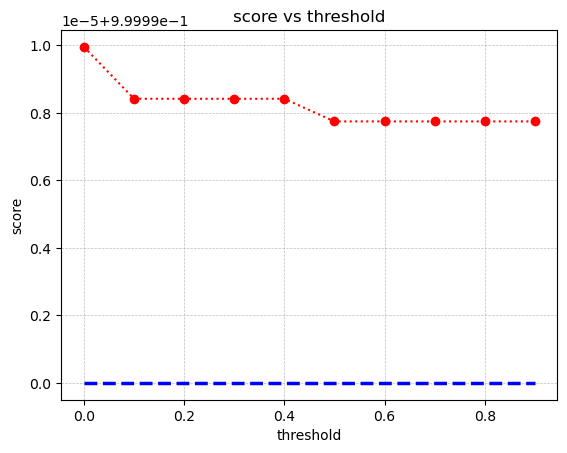

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.005 r + -7.520 r_dot + -296.951 q
(q)' = 0.997 q_dot
(q_dot)' = 7.474 r + -146.713 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977455895326
Iteration: 68
[-0.19516572 -0.04997246  0.11505422  0.0296126 ]


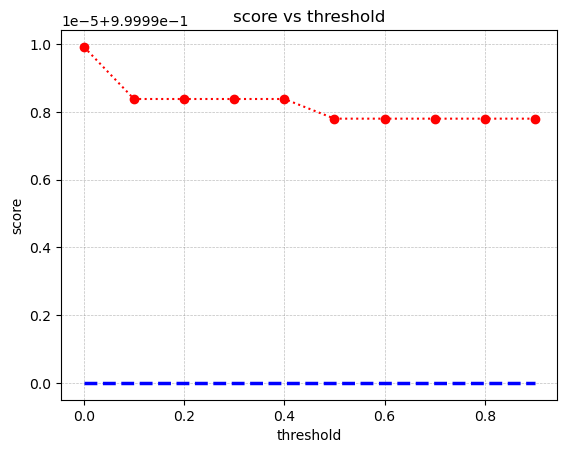

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.965 r + -7.518 r_dot + -296.885 q
(q)' = 0.997 q_dot
(q_dot)' = 7.359 r + -146.862 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977998309179
Iteration: 69
[-0.49081726  0.1808671  -0.07286203  0.39390128]


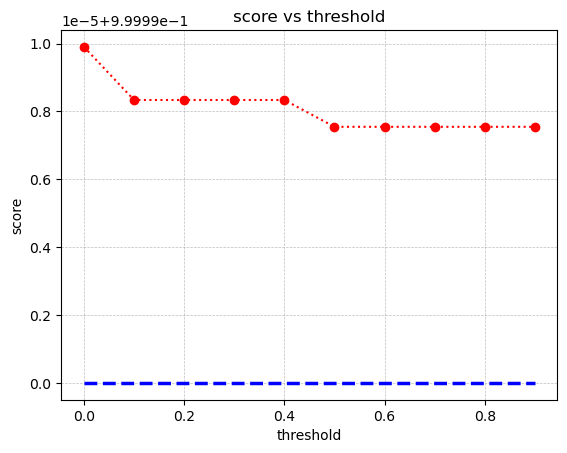

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.066 r + -7.522 r_dot + -297.051 q
(q)' = 0.997 q_dot
(q_dot)' = 7.689 r + -146.434 q + 2.868 q_dot + -2.739 q^2 q_dot
Score on training data:
0.999997547252283
Iteration: 70
[0.28667786 0.11938049 0.00382419 0.08350355]


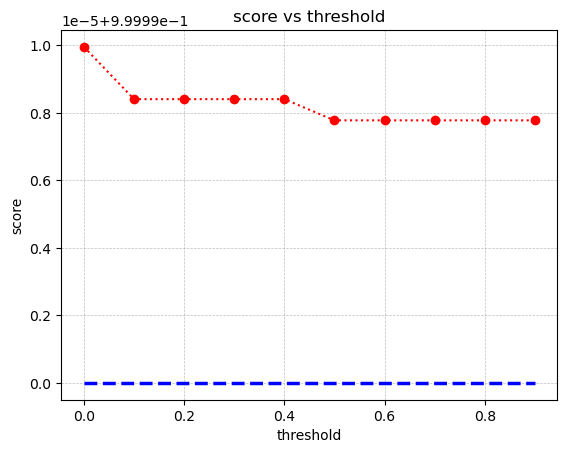

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.989 r + -7.519 r_dot + -296.924 q
(q)' = 0.997 q_dot
(q_dot)' = 7.444 r + -146.752 q + 2.881 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977764890143
Iteration: 71
[ 0.14705046  0.44425114 -0.03155232  0.31145444]


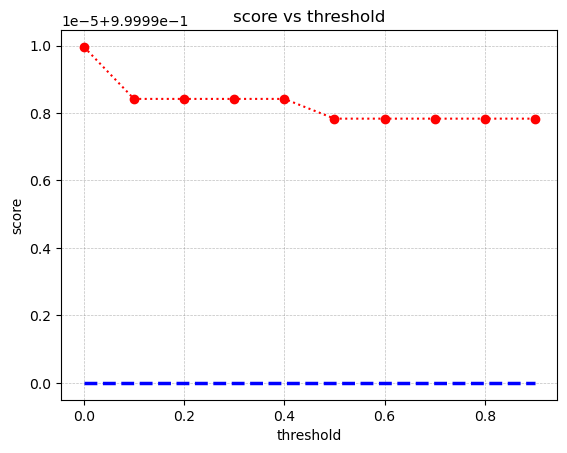

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.976 r + -7.519 r_dot + -296.902 q
(q)' = 0.997 q_dot
(q_dot)' = 7.376 r + -146.840 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999978331486242
Iteration: 72
[-0.08206754  0.23547757 -0.18809299  0.06300379]


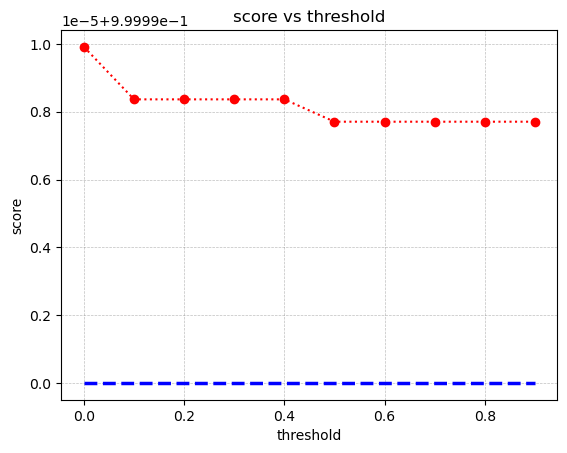

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.002 r + -7.520 r_dot + -296.946 q
(q)' = 0.997 q_dot
(q_dot)' = 7.482 r + -146.703 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977066925387
Iteration: 73
[ 0.25269371 -0.22753441 -0.16434295 -0.48613473]


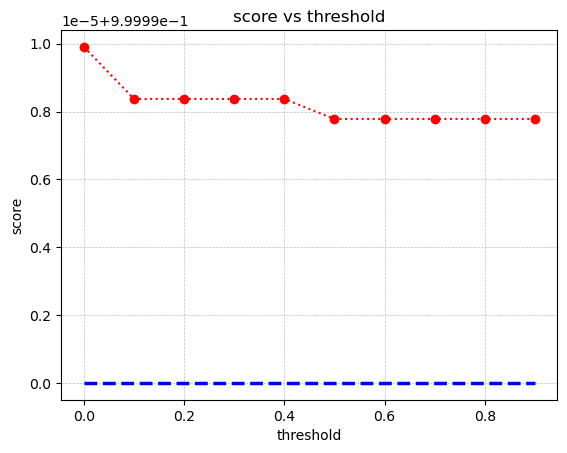

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.971 r + -7.518 r_dot + -296.894 q
(q)' = 0.997 q_dot
(q_dot)' = 7.381 r + -146.834 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977838838412
Iteration: 74
[-0.15978979 -0.06774748 -0.03636262 -0.04762398]


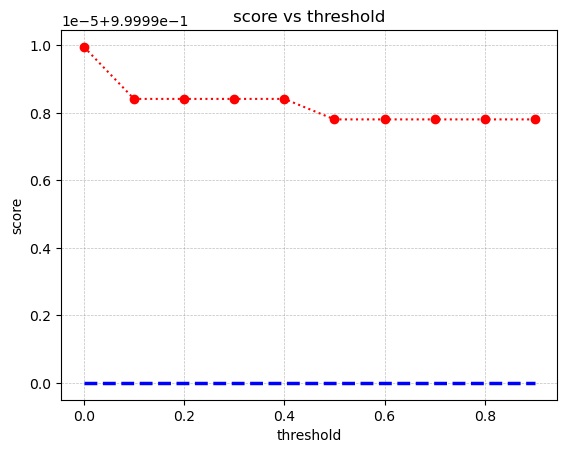

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.979 r + -7.519 r_dot + -296.908 q
(q)' = 0.997 q_dot
(q_dot)' = 7.413 r + -146.792 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997806785529
Iteration: 75
[ 0.3560358  -0.23436512  0.28523741 -0.39556064]


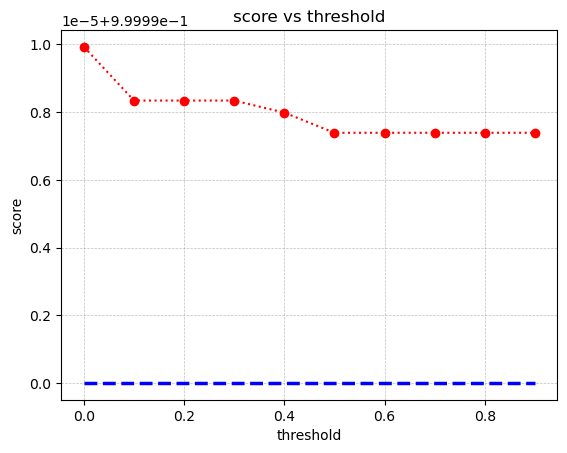

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.136 r + -7.525 r_dot + -297.168 q
(q)' = 0.997 q_dot
(q_dot)' = 7.918 r + -146.137 q + 2.857 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999973904008093
Iteration: 76
[-0.19060089  0.08492171  0.1602885   0.11827604]


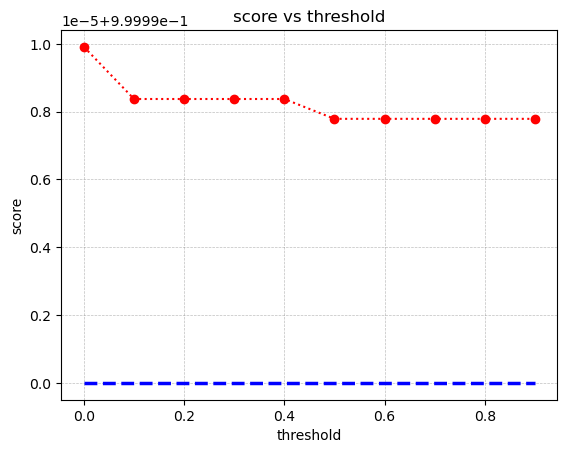

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.968 r + -7.518 r_dot + -296.889 q
(q)' = 0.997 q_dot
(q_dot)' = 7.367 r + -146.853 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977893041203
Iteration: 77
[-0.18946227 -0.47216629  0.49022556  0.0303721 ]


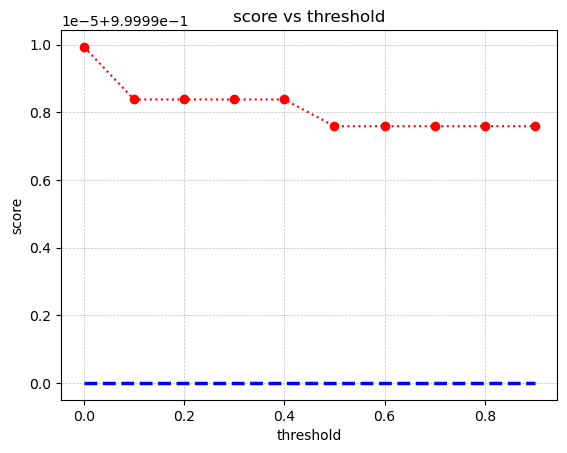

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.060 r + -7.522 r_dot + -297.041 q
(q)' = 0.997 q_dot
(q_dot)' = 7.653 r + -146.480 q + 2.870 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975920730314
Iteration: 78
[-0.31771292  0.36266383 -0.47792244 -0.01650606]


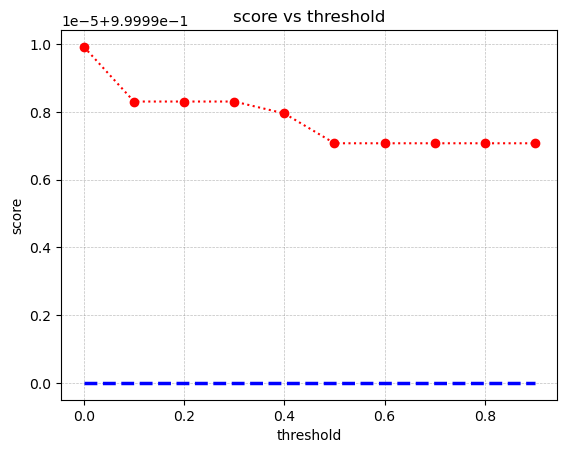

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.260 r + -7.531 r_dot + -297.373 q
(q)' = 0.997 q_dot
(q_dot)' = 8.313 r + -145.623 q + 2.837 q_dot + -2.741 q^2 q_dot
Score on training data:
0.9999970774487057
Iteration: 79
[ 0.11990073  0.49523801 -0.22569631  0.20801075]


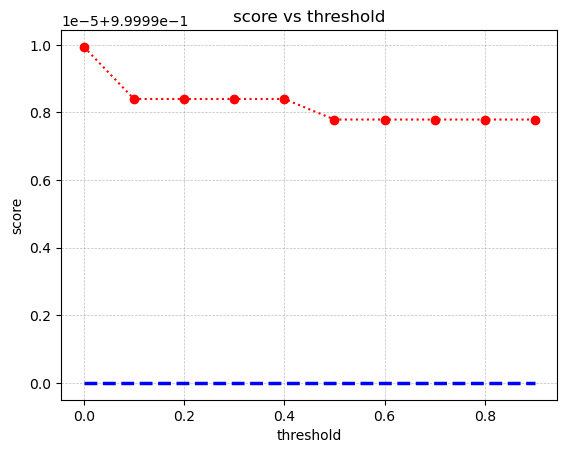

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.977 r + -7.519 r_dot + -296.904 q
(q)' = 0.997 q_dot
(q_dot)' = 7.399 r + -146.811 q + 2.883 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977912760962
Iteration: 80
[ 0.42693763 -0.21050192  0.22550522  0.30521104]


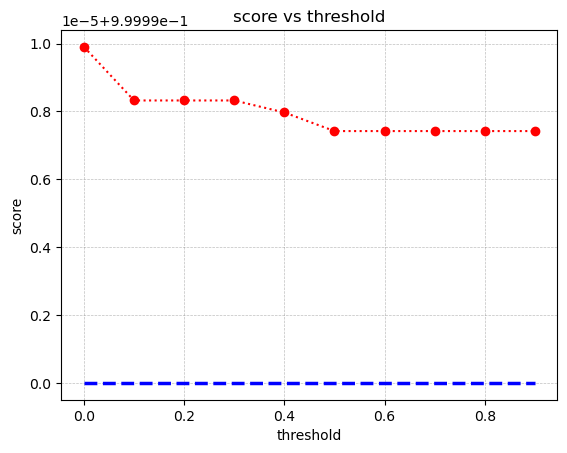

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.119 r + -7.525 r_dot + -297.139 q
(q)' = 0.997 q_dot
(q_dot)' = 7.871 r + -146.198 q + 2.859 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999974212608629
Iteration: 81
[-0.47573161 -0.09830134 -0.31116784 -0.49567267]


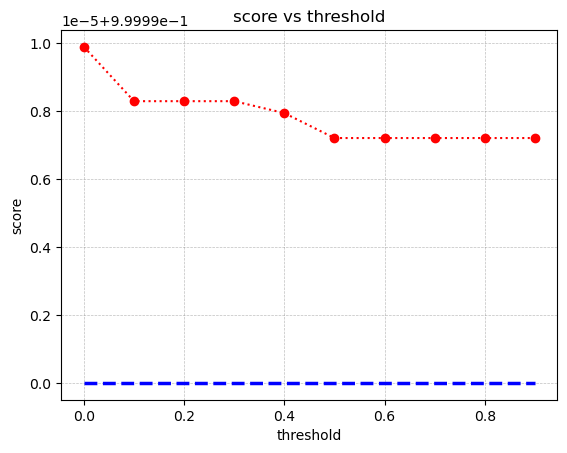

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.202 r + -7.528 r_dot + -297.277 q
(q)' = 0.997 q_dot
(q_dot)' = 8.139 r + -145.849 q + 2.846 q_dot + -2.741 q^2 q_dot
Score on training data:
0.9999972143078479
Iteration: 82
[ 0.22615583  0.00460757 -0.1243144   0.13468709]


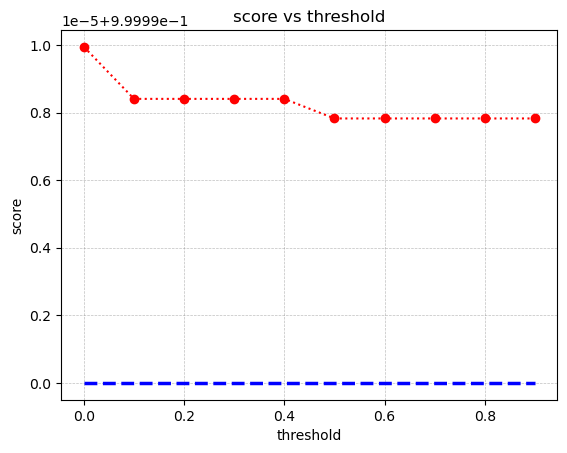

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.964 r + -7.518 r_dot + -296.883 q
(q)' = 0.997 q_dot
(q_dot)' = 7.356 r + -146.867 q + 2.885 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997825509405
Iteration: 83
[-0.46400862  0.15285145  0.33193262  0.391793  ]


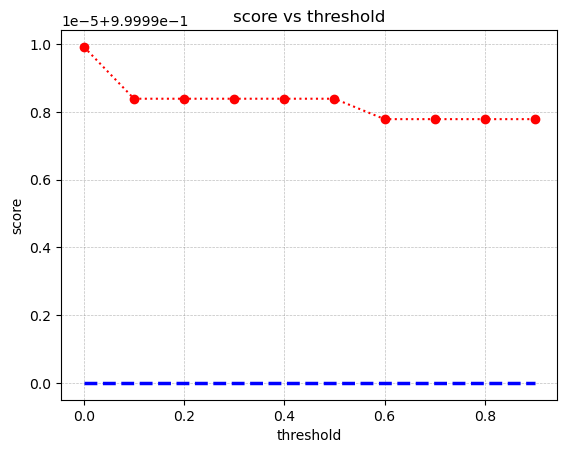

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.975 r + -7.519 r_dot + -296.901 q
(q)' = 0.997 q_dot
(q_dot)' = 7.375 r + -146.842 q + 2.884 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977887901899
Iteration: 84
[ 0.37620584  0.27746623  0.32495985 -0.04898804]


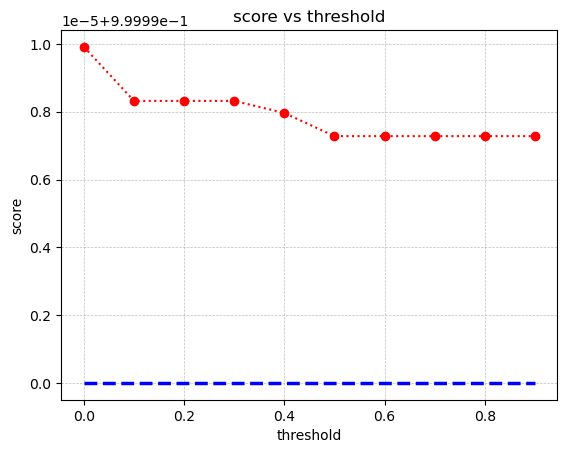

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.177 r + -7.527 r_dot + -297.236 q
(q)' = 0.997 q_dot
(q_dot)' = 8.048 r + -145.967 q + 2.851 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999972790574048
Iteration: 85
[ 0.12539744 -0.15622171 -0.43890332  0.39539632]


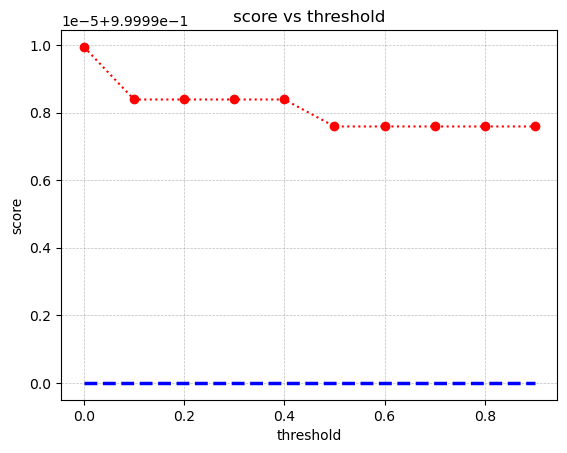

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.063 r + -7.522 r_dot + -297.047 q
(q)' = 0.997 q_dot
(q_dot)' = 7.665 r + -146.465 q + 2.870 q_dot + -2.739 q^2 q_dot
Score on training data:
0.999997590766017
Iteration: 86
[-0.07885688 -0.19617403 -0.31523854  0.02202406]


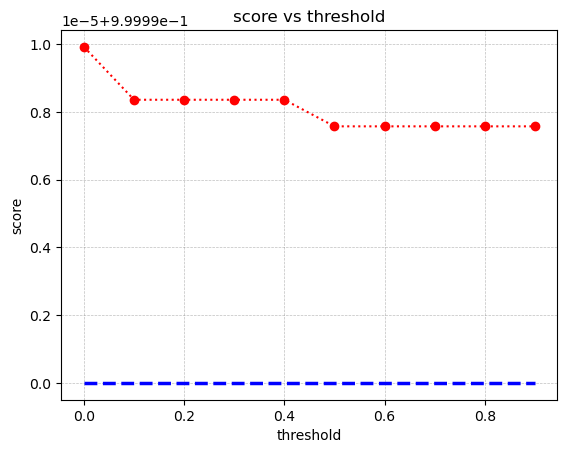

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.059 r + -7.522 r_dot + -297.040 q
(q)' = 0.997 q_dot
(q_dot)' = 7.662 r + -146.470 q + 2.870 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975746698617
Iteration: 87
[-0.10158166 -0.08755869  0.29770855  0.12844366]


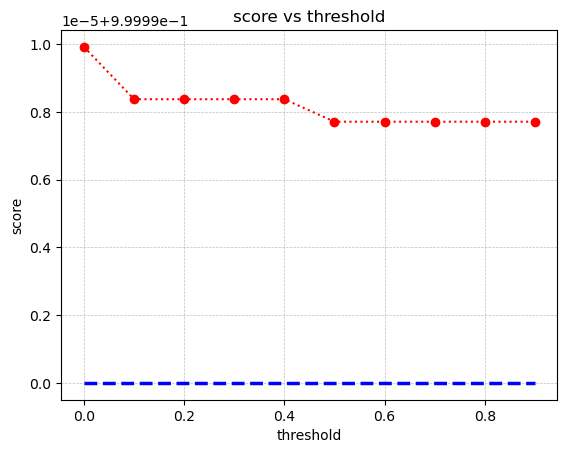

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.003 r + -7.520 r_dot + -296.948 q
(q)' = 0.997 q_dot
(q_dot)' = 7.480 r + -146.706 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977112841401
Iteration: 88
[ 0.26493477 -0.42915185  0.32972197 -0.28012848]


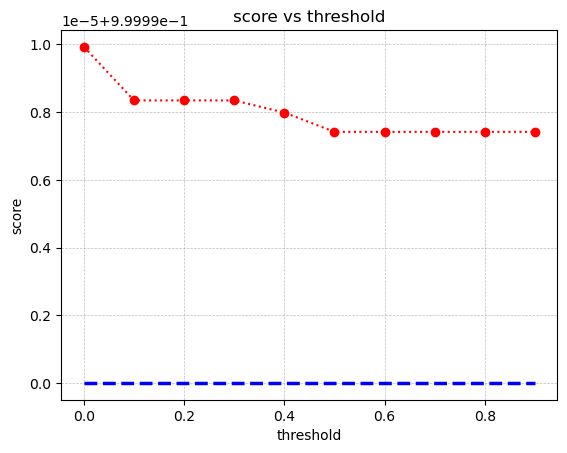

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.125 r + -7.525 r_dot + -297.149 q
(q)' = 0.997 q_dot
(q_dot)' = 7.881 r + -146.185 q + 2.859 q_dot + -2.740 q^2 q_dot
Score on training data:
0.9999974184675877
Iteration: 89
[ 0.49504196 -0.41044768 -0.08584761 -0.32818578]


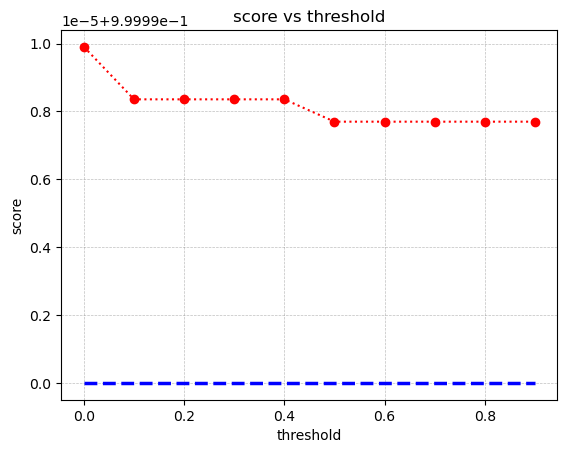

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.004 r + -7.520 r_dot + -296.949 q
(q)' = 0.997 q_dot
(q_dot)' = 7.485 r + -146.699 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997698057813
Iteration: 90
[-0.0582981   0.40452958  0.14976977 -0.28628427]


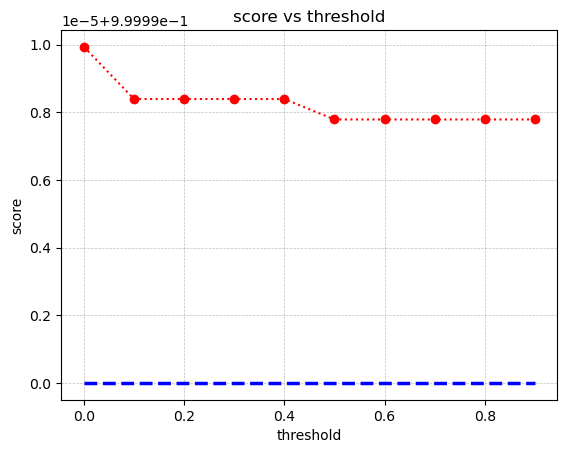

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.976 r + -7.519 r_dot + -296.902 q
(q)' = 0.997 q_dot
(q_dot)' = 7.392 r + -146.819 q + 2.883 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997790853827
Iteration: 91
[-0.16091356  0.20926096  0.48416655  0.05475512]


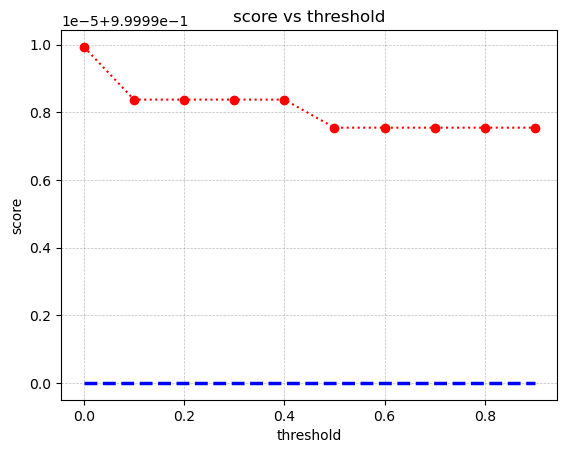

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.077 r + -7.523 r_dot + -297.070 q
(q)' = 0.997 q_dot
(q_dot)' = 7.704 r + -146.414 q + 2.868 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975458890213
Iteration: 92
[ 0.15663444  0.23689641 -0.33281319  0.28361035]


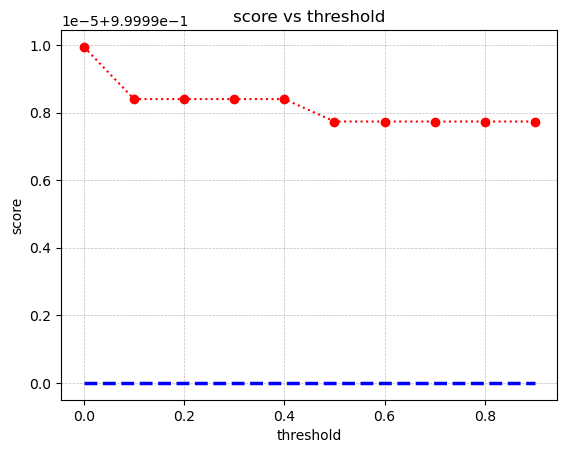

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.003 r + -7.520 r_dot + -296.946 q
(q)' = 0.997 q_dot
(q_dot)' = 7.477 r + -146.709 q + 2.879 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997735538212
Iteration: 93
[ 0.36756101 -0.15299516 -0.02727719 -0.1369656 ]


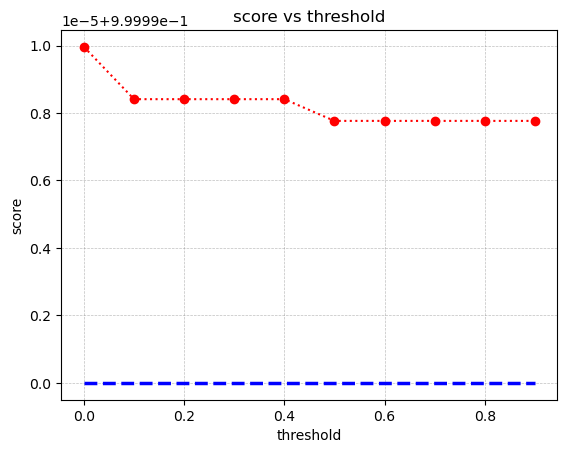

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.004 r + -7.520 r_dot + -296.947 q
(q)' = 0.997 q_dot
(q_dot)' = 7.463 r + -146.727 q + 2.880 q_dot + -2.738 q^2 q_dot
Score on training data:
0.999997766507488
Iteration: 94
[ 0.09290019 -0.07461909 -0.23773721  0.01557629]


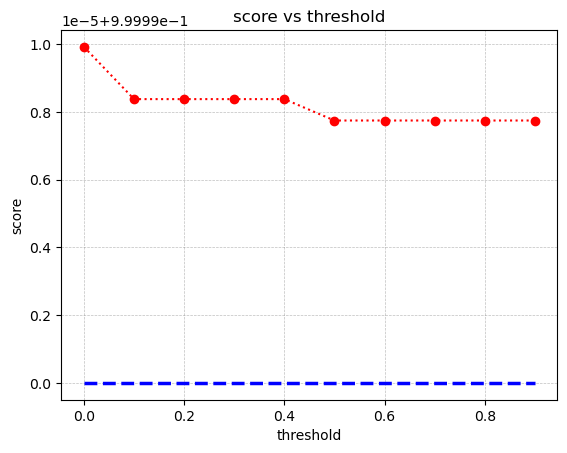

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.989 r + -7.519 r_dot + -296.923 q
(q)' = 0.997 q_dot
(q_dot)' = 7.433 r + -146.767 q + 2.881 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977485696129
Iteration: 95
[ 0.23519167 -0.07299867  0.23652707  0.05873552]


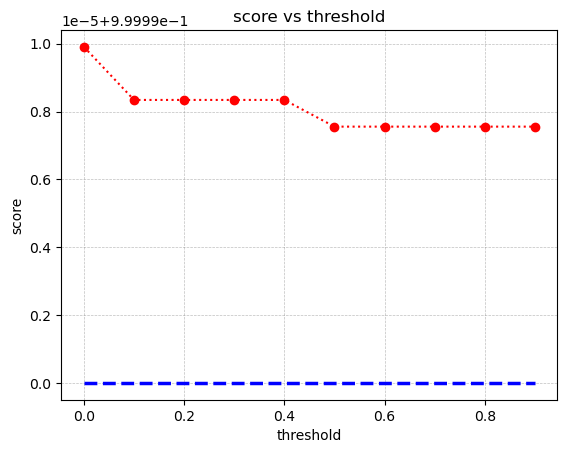

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.063 r + -7.522 r_dot + -297.046 q
(q)' = 0.997 q_dot
(q_dot)' = 7.681 r + -146.445 q + 2.869 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975550130529
Iteration: 96
[ 0.49537547 -0.1076065  -0.46446272  0.04969948]


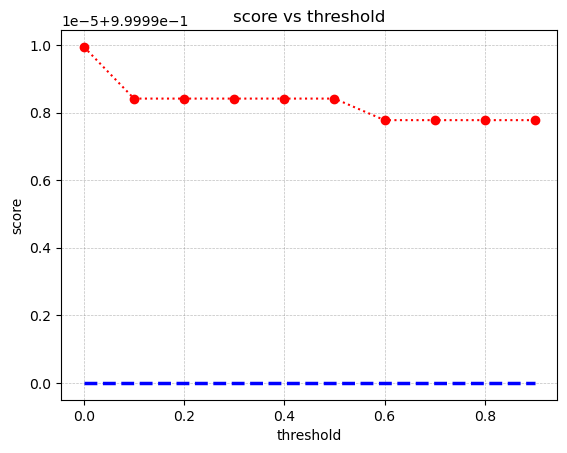

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -333.991 r + -7.519 r_dot + -296.927 q
(q)' = 0.997 q_dot
(q_dot)' = 7.420 r + -146.784 q + 2.882 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999977777358671
Iteration: 97
[ 0.39695488 -0.16300289  0.16030158  0.07642314]


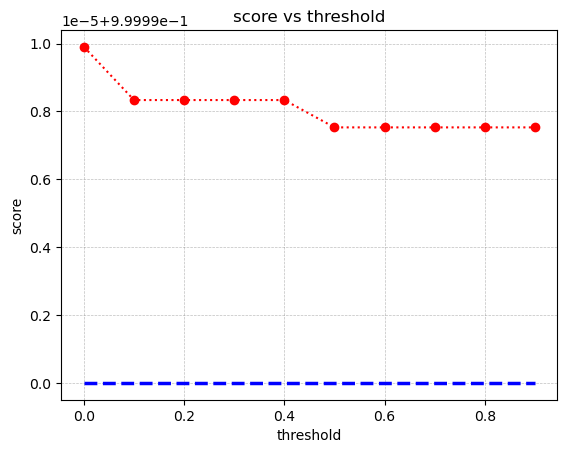

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.074 r + -7.523 r_dot + -297.065 q
(q)' = 0.997 q_dot
(q_dot)' = 7.724 r + -146.389 q + 2.867 q_dot + -2.739 q^2 q_dot
Score on training data:
0.9999975305700213
Iteration: 98
[-0.44407425 -0.36632908 -0.02327903  0.23533033]


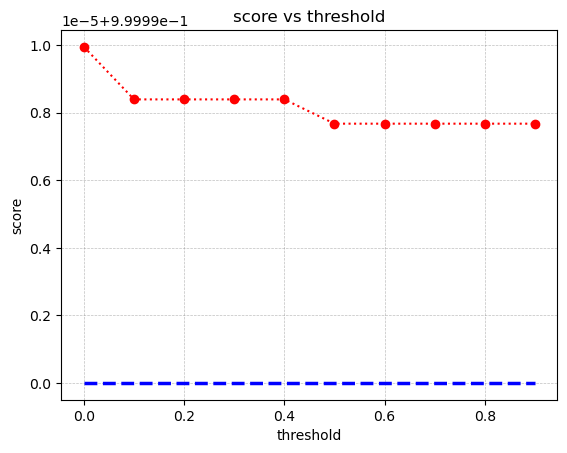

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.034 r + -7.521 r_dot + -296.998 q
(q)' = 0.997 q_dot
(q_dot)' = 7.589 r + -146.564 q + 2.873 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976740422201
Iteration: 99
[-0.48695     0.00760039  0.07838422  0.37399612]


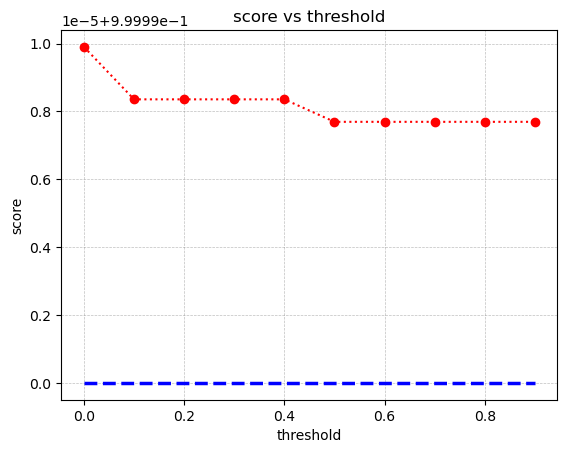

--------------------------------------------------
optimal_threshold: 0.9
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -334.007 r + -7.520 r_dot + -296.954 q
(q)' = 0.997 q_dot
(q_dot)' = 7.495 r + -146.686 q + 2.878 q_dot + -2.738 q^2 q_dot
Score on training data:
0.9999976934546433


In [7]:
n_initial_conditions = 100

for iter in range(n_initial_conditions):

    print(f'Iteration: {iter}')

     # generate the data for testing
    start = 0
    end = 100
    step = 0.01
    n_points = int((end-start)/step)
    t_span = [start, end]

    # generate random initial condition between -2 and 2
    x0 = np.random.rand(4) * 1 - 0.5
    print(x0)

    sol = solve_ivp(coupled_vdp_ac, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
    t = np.arange(start, end+step/10, step)
    x = sol.sol(t).T

    # The feature names of the columns of y
    feature_names = ['r', 'r_dot', 'q', 'q_dot']

    functions = [lambda x : x,
                lambda x: x ** 2,
                lambda x,y: x ** 2 * y
                ]

    function_names = [lambda x : str(x), 
                    lambda x: str(x) + "^2",
                    lambda x,y: str(x) + "^2 " + str(y)
                    ]


    lib_custom = CustomLibrary(library_functions=functions, 
                            function_names=function_names)
    lib_custom.fit(x)
    lib_custom.transform(x)

    feature_library = lib_custom


    feature_library.fit(x)

    # Differentiation method
    differentiation_method = ps.FiniteDifference(order=2)

    scores = []

    threshold_start = 0
    threshold_end = 1
    threshold_step = 0.1

    thresholds = np.arange(threshold_start, threshold_end, threshold_step)

    for threshold in thresholds:
        opt = ps.STLSQ(threshold=threshold)
        model=ps.SINDy(differentiation_method=differentiation_method,
                    feature_library = feature_library,
                    feature_names=feature_names, 
                    optimizer=opt)
        model.fit(x,t=t)
        scores.append(model.score(x,t=t))

    score_threshold = 0.99999
    threshold_line = np.ones(thresholds.shape) * score_threshold

    plt.plot(thresholds, scores, 'ro:')
    plt.plot(thresholds, threshold_line, 'b--', linewidth=2.5)
    plt.xlabel('threshold')
    plt.ylabel('score')
    plt.yscale('linear')
    plt.title('score vs threshold')
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.show()



    optimal_threshold = None
    for i in range(len(scores)):
        if scores[i] > score_threshold:
            optimal_threshold = thresholds[i]
        else:
            break

    print('-'*50)
    print(f'optimal_threshold: {optimal_threshold}')
    print('-'*50)


    # optimal_threshold = 0.015 # for testing

    if optimal_threshold is None:
        raise ValueError('No threshold found that gives a score > score_threshold')
    else:
        opt = ps.STLSQ(
            threshold=optimal_threshold
            )
        model=ps.SINDy(differentiation_method=differentiation_method,
                        feature_library=feature_library,
                        feature_names=feature_names,
                        optimizer=opt)
        model.fit(x,t=t)
        print('Identified model:')
        model.print()

        print('Score on training data:')
        print(model.score(x,t=t))

    coefficients = model.coefficients()

    if iter == 0:
        z = np.array(coefficients)
    else:    
        z = np.vstack((z, coefficients))

In [7]:
z = z.reshape(n_initial_conditions,4,14)
z[5,:,:]

array([[ 0.00000000e+00,  9.95798995e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-3.38134829e+02, -7.33760467e+00, -3.03743558e+00,
         0.00000000e+00,  1.34005807e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -5.16453239e+01,
         0.00000000e+00,  0.00000000e+00,  1.34132804e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         9.99974946e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 2.28445413e+01,  4.95999964e-01, -1.22708765e+00,
         2.87141527e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.

In [8]:
# getting the feature names
for idx, name in enumerate(model.get_feature_names()):
    print(f"{idx+1} : {name}")


# find the mean of the coefficients
mean = z.mean(axis=0)
# find the standard deviation of the coefficients
std = z.std(axis=0)
# create the zeroing criteria. If the standard deviation is greater than the mean, then zero out the coefficient
coeff_var = np.abs(std)/np.abs(mean)

# zero out the terms with a large standard deviation
mean[coeff_var>1] = 0

#print the mean and standard deviation

print("mean: ")
print(mean)

print("std: ")
print(std)

print('coeff_var: ')
print(coeff_var)


1 : r
2 : r_dot
3 : q
4 : q_dot
5 : r^2
6 : r_dot^2
7 : q^2
8 : q_dot^2
9 : r^2 r_dot
10 : r^2 q
11 : r^2 q_dot
12 : r_dot^2 q
13 : r_dot^2 q_dot
14 : q^2 q_dot
mean: 
[[ 0.00000000e+00  9.97144373e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.38008340e+02 -7.34423339e+00 -3.03616248e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.99975508e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 2.21474637e+01  3.81968228e-01 -1.23340360e+00  2.86265768e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 

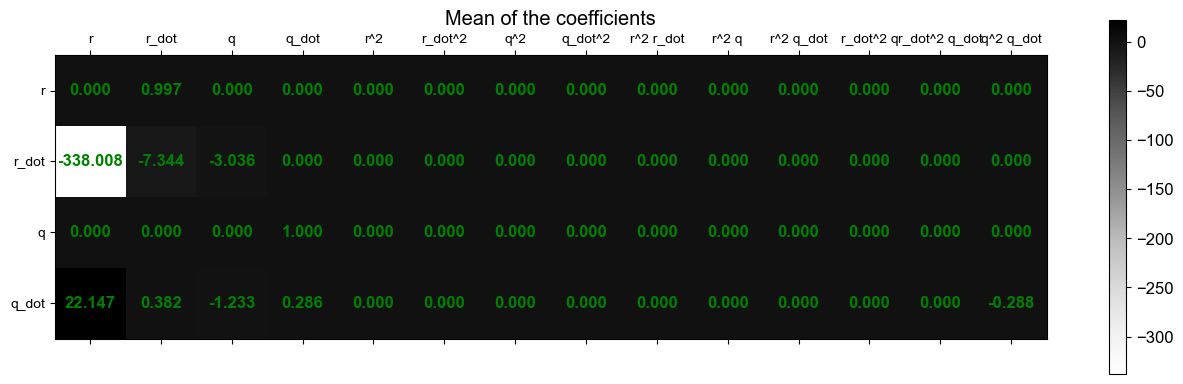

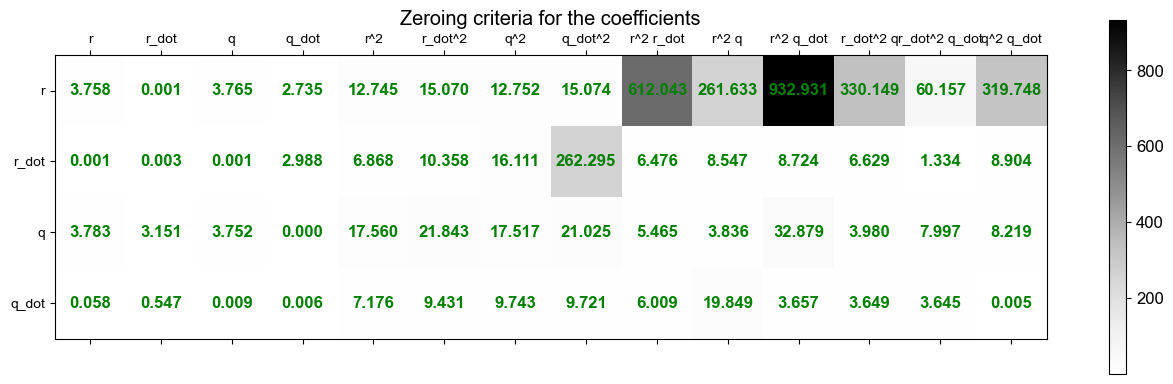

In [9]:
directory = case + '_coupling_custom'

if not os.path.exists(directory):
    os.makedirs(directory)

xticklabels = model.get_feature_names()
yticklabels = feature_names


plt.matshow(mean, cmap='Greys')
for i in range(mean.shape[0]):
    for j in range(mean.shape[1]):
        plt.annotate("{:.3f}".format(mean[i, j]), xy=(j, i), ha='center', va='center', color='green', fontsize=12, fontweight='bold')
plt.xticks(ticks=range(mean.shape[1]),labels=xticklabels, fontsize=10)
plt.yticks(ticks=range(mean.shape[0]),labels=yticklabels, fontsize=10)
plt.title("Mean of the coefficients")
plt.savefig(directory + '/' + "mean.pdf", dpi=300)
plt.colorbar()
plt.show()


plt.matshow(coeff_var, cmap='Greys')
for i in range(coeff_var.shape[0]):
    for j in range(coeff_var.shape[1]):
        plt.annotate("{:.3f}".format(coeff_var[i, j]), xy=(j, i), ha='center', va='center', color='green', fontsize=12, fontweight='bold')
plt.xticks(ticks=range(coeff_var.shape[1]),labels=xticklabels, fontsize=10)
plt.yticks(ticks=range(coeff_var.shape[0]),labels=yticklabels, fontsize=10)
plt.title("Coefficient of variation for the coefficients")
plt.savefig(directory + '/' + "coeff_var.pdf", dpi=300)
plt.colorbar()
plt.show()

In [10]:
# # Reduced Order Model
case='ROM_model'

Cd = 1.2
CL0 = 0.5
rho0 = 1.167e-6
D = 42
U0 = 0.1e3
L0 = 210
lbda = 0.24
A = 12
St = 0.08
zeta = 0.2
omega1 = 18.4097
phi_expr = -0.236617

def coupled_vdp_ac(t, x, args=(Cd, CL0, rho0, D, U0, L0, lbda, A, St, zeta, omega1, phi_expr)):
    # r = x[0]
    # rdot = x[1]
    # q = x[2]
    # qdot = x[3]
    omega_s = (2 * np.pi * St * U0) / D
    alpha = (( CL0 * rho0 * D * U0 ** 2 * L0)/4) * phi_expr

    xdot = np.zeros_like(x)
    xdot[0] = x[1] 
    xdot[1] = -2 * zeta * omega1 * x[1] - (( Cd * rho0 * D * U0 * L0) / 2) * (phi_expr) ** 2 * x[1] - omega1 ** 2 * x[0] + alpha * x[2]
    xdot[2] = x[3]
    xdot[3] = (A/D) * ((phi_expr) * (xdot[1])) - lbda * omega_s * (x[2] ** 2 - 1) * x[3]- omega_s ** 2 * x[2]

    return xdot

def id_sys(t, x):
    xdot = np.zeros_like(x)
    xdot[0] = 0.997 * x[1]
    xdot[1] = -338.049 * x[0] -7.343 * x[1] - 3.037 * x[2] 
    xdot[2] = x[3]
    xdot[3] = 22.199 * x[0] + 0.387 * x[1] - 1.233 * x[2] +0.286 * x[3] - 0.288 * (x[2]**2) * x[3]
    return xdot


# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]

# generate random initial condition between -2 and 2
x0 = np.random.rand(4) * 0.1 -  0.05
print(x0)

sol = solve_ivp(coupled_vdp_ac, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
t = np.arange(start, end+step/10, step)
x_true = sol.sol(t).T

sol = solve_ivp(id_sys, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
x_id = sol.sol(t).T  

# plt.plot(t,x_true[:,0])
# plt.plot(t,x_id[:,0])
# plt.show()

[-0.04050674  0.03712148  0.02935121  0.01503526]


In [11]:
directory = case + '_coupling_custom'

if not os.path.exists(directory):
    os.makedirs(directory)

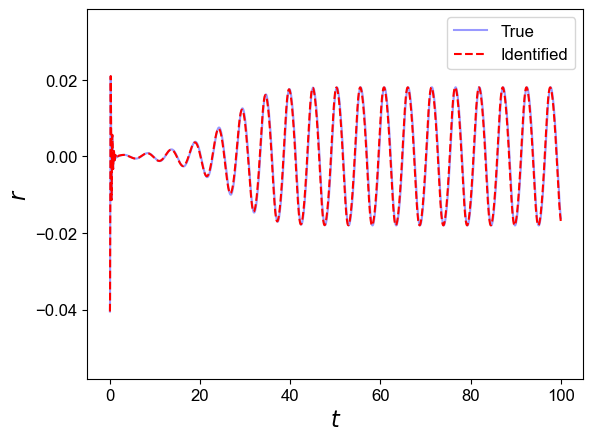

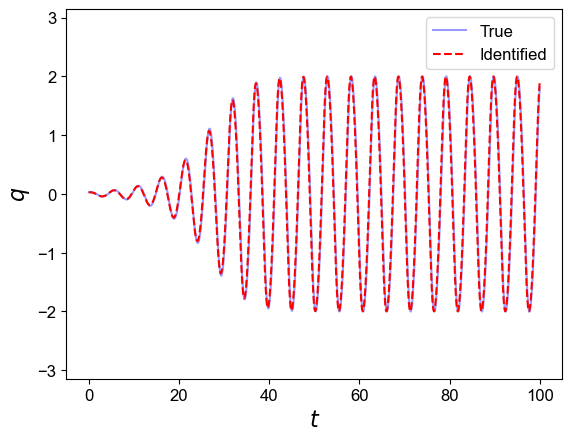

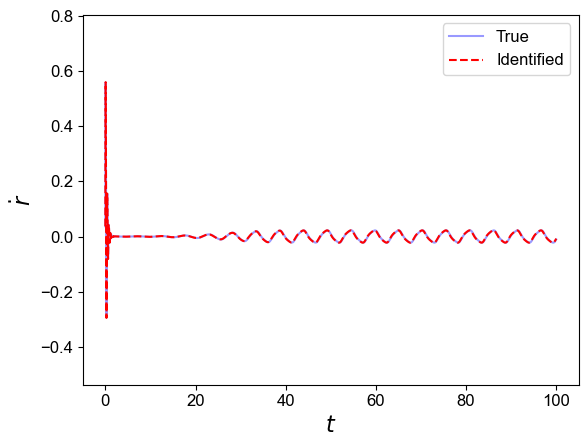

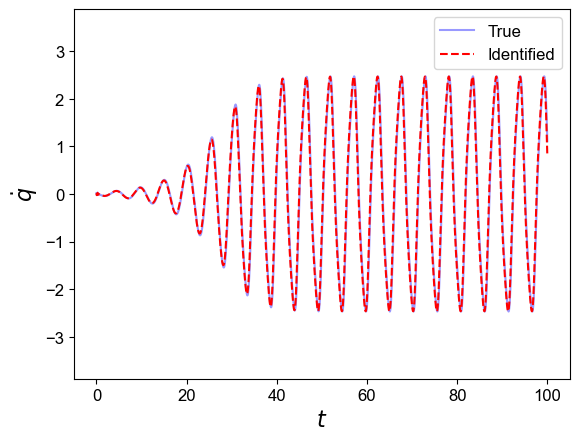

In [12]:
# plot the solution

plt.rcdefaults()
plt.rcParams.update({'font.size': 12})

plt.rcParams['font.family'] = 'Sans-Serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# x1
plot_comparison(t, x_true[:,0], x_id[:,0], "t", "r", "r", directory=directory)

# x2
plot_comparison(t, x_true[:,2], x_id[:,2], "t", "q", "q",directory=directory)

# x1 dot
plot_comparison(t, x_true[:,1], x_id[:,1], "t", "\dot{r}", "rdot", directory=directory)

# x2 dot
plot_comparison(t, x_true[:,3], x_id[:,3], "t", "\dot{q}", "qdot", directory=directory)

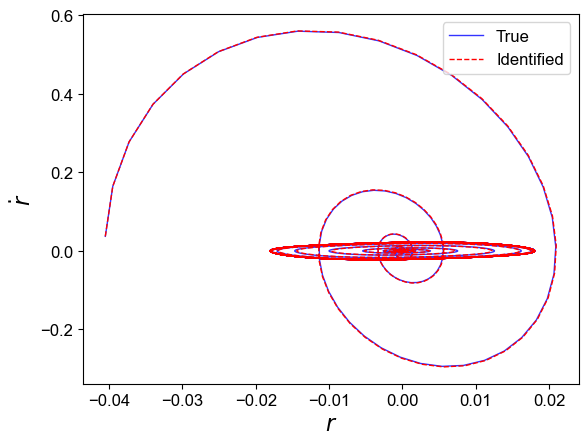

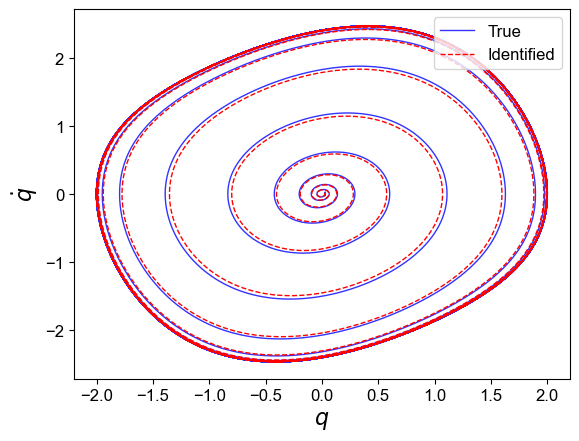

In [13]:
# Phase Portrait Oscillator 1
plot_pp(x_true[:,0], x_true[:,1], x_id[:,0], x_id[:,1], "r", "\dot{r}", "pp_r", directory=directory)

# Phase Portrait Oscillator 2
plot_pp(x_true[:,2], x_true[:,3], x_id[:,2], x_id[:,3], "q", "\dot{q}", "pp_q", directory=directory)

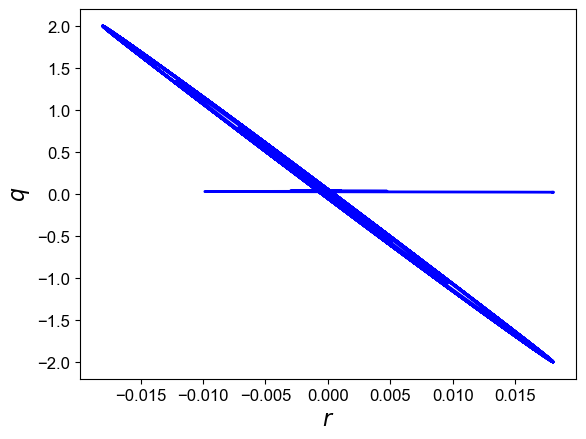

In [14]:
# Displacement Lissajous Figure
plot_lissajous(x[:,0], x[:,2], "r", "q", "lissajous_disp", directory=directory)

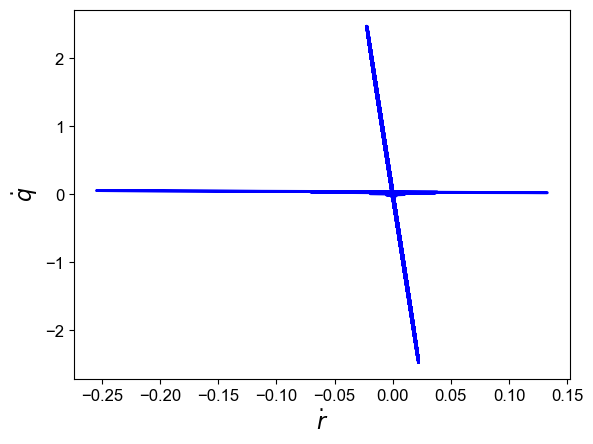

In [15]:
# Velocity Lissajous Figure
plot_lissajous(x[:,1], x[:,3], "\dot{r}", "\dot{q}", "lissajous_vel", directory=directory)